# SwarmConvFormer (SCF) - Full Experiment Suite (single, coherent notebook)

This notebook extends the already-validated `SwarmConvFormer_FIXED.ipynb`
pipeline (GWO stagnation fix, real feature-selection step T=65, unified
focal-loss training, Effective-Number-of-Samples class weighting) with the
full set of additional experiments needed for the paper's tables: baseline
comparisons (Table 3), the ablation study (Table 5), the activation-function
comparison (Table 5b), feature-permutation importance (Table 5c),
initialization-strategy comparison (Table 5d), latency/quantization
benchmarking (Table 6), a real aggregated GWO convergence figure, filter-bank
orthogonality statistics, and a symmetric-vs-asymmetric fusion ablation.

**Everything in this file (code, comments, docstrings, markdown, print
statements) is written in English only.**

## Important: this is computationally expensive

The original 5-seed SwarmConvFormer protocol alone took roughly **121
minutes** on the machine it was validated on. This notebook adds many more
training runs on top of that:

| Section | Training runs | Rough scale vs. one 5-seed SCF run |
|---|---|---|
| 1. Baseline models (Table 3) | 5 models x 5 seeds = 25 runs | ~2-4x (smaller/simpler models, similar epoch budget) |
| 2. Ablation study (Table 5) | 4 leave-one-out configs x 5 seeds = 20 runs (the 5th, "full", reuses the main run) | ~2-3x |
| 3. Activation comparison (Table 5b) | 5 activations x 5 seeds = 25 runs | ~2-4x |
| 4. Permutation importance (Table 5c) | 0 new training runs (reuses the 5 trained SCF models), but ~65 features x 5 seeds x repeats inference passes | Inference-only, minutes to ~1 hour |
| 5. Initialization comparison (Table 5d) | 3 new strategies x 5 seeds = 15 runs (GWO strategy reuses the main run) | ~1.5-3x |
| 6. Latency & quantization (Table 6) | 0 new training runs (reuses seed-42 SCF model) | Minutes |
| 7. GWO convergence aggregation | 0 new training runs (reuses `results_seed_*.json`) | Seconds |
| 8. Filter orthogonality | 0 new training runs (reuses trained stem kernels) | Seconds |
| 9. Symmetric fusion ablation | 5 seeds = 5 runs (reuses the asymmetric numbers from the main run) | ~1x |

**Rough total for everything below (excluding the main 5-seed run itself):
on the order of a full working day on a single machine without a GPU**,
dominated by Sections 1, 2, 3 and 5 (roughly 85 additional full training
runs). With a GPU this should be substantially faster (the original 5-seed
run's ~121 minutes was itself measured on CPU-only hardware per its own log).

## Resumability

Every experiment cell below **checks for its own output file(s) first** and
skips re-training (loading the cached JSON instead) if they already exist.
This means:
- You can stop the kernel/runtime at any point and resume later; already
  completed runs are not redone.
- All output files land in a single `results/` folder (created if needed) so
  you can zip/send back that one folder when you are done.

## `SMOKE_TEST` flag

Set in Section 0 below. When `True` (the default as shipped), every section
runs against a small SYNTHETIC dataset with drastically reduced
epochs/iterations/permutation counts/latency-benchmark N, purely to confirm
the whole notebook executes top-to-bottom without errors. **Set
`SMOKE_TEST = False` before running on your real InSDN data.**

## Note on Table 3b

Table 3b (literature/SOTA comparison) is not implemented here: it is a table
of externally published numbers from other papers, not something this
pipeline computes. See the markdown note at the end of the notebook.

# Part A: Core Pipeline (original 5-seed protocol)

This part is the same pipeline validated
(fix log below), translated to English and lightly extended with a
`results/` output folder, a `SMOKE_TEST` flag and resumability so the new
experiment sections in Part B can reuse its functions and cached outputs.

## Fix log (each fix is tied to a concretely verified problem)

- **[F1] GWO premature convergence** - confirmed by re-running the original
  algorithm independently: the alpha value froze at the same number for all
  12 iterations even though population fitness variance stayed high. **Fix**:
  stagnation detection + diversity injection (randomly re-initialize the
  worst fraction of the wolves when stagnant); verified this makes alpha
  actually improve across iterations.
- **[F2] Feature dimension 77 vs. the paper's claimed T=64/T=65** - added a
  real variance-filtering step (`select_informative_features`) that actually
  performs the filtering the paper describes and prints the real resulting T,
  instead of asserting an unverified number.
- **[F3] "Reproducibility verification" was hard-coded constants** - replaced
  with a function that checks the REAL in-memory split sizes.
- **[F4] Two contradictory `model.fit()` runs** with two different losses,
  the second one never finishing execution in the original notebook.
  **Fix**: one consistent strategy (class-weighted focal loss), one explicit
  flag to turn oversampling on/off instead of two silently-conflicting runs.
- **[F5] Non-existent "R2L" class** - InSDN (Elsayed et al., 2020) has 8
  classes (Normal, DoS, DDoS, Probe, BFA, Web-Attack, BOTNET, U2R), no R2L.
- **[F6] Stratified split with a floor for very rare classes**, printing real
  per-class counts instead of assuming them.

## Run protocol

Run the notebook cell by cell. The final cell of Part A runs the 5-seed
protocol ([42, 123, 7, 2024, 31415]) and writes `results/results_seed_*.json`
and `results/results_summary.csv`.

**Prerequisite (real data):** place `Normal_data.csv`, `metasploitable-2.csv`
and `OVS.csv` inside an `InSDN_DatasetCSV/` folder next to this notebook (or
change `DATA_DIR` below).

## A0. Setup, imports and shared configuration

In [1]:
import os, time, json, warnings, random, csv, gc
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.losses import CategoricalCrossentropy
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              precision_score, recall_score, f1_score, matthews_corrcoef)
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices("GPU"))

# ------------------------------------------------------------------
# SMOKE_TEST: set this to False before running on real InSDN data.
# While True, every section below uses a small synthetic InSDN-shaped
# dataset and drastically reduced budgets (epochs/GWO iterations/
# permutation repeats/latency N), purely to validate that every cell in
# this notebook executes correctly end-to-end.
# ------------------------------------------------------------------
SMOKE_TEST = False

# ------------------------------------------------------------------
# General configuration - edit here only
# ------------------------------------------------------------------
DATA_DIR = "InSDN_DatasetCSV"          # folder holding the three real CSV files
REMOVED_COLUMNS = ["Flow ID", "Src IP", "Dst IP", "Timestamp", "Src Port", "Dst Port"]
VARIANCE_THRESHOLD = 1e-6
USE_OVERSAMPLING = False               # [F4] one explicit, documented flag
SPLIT_SEED = 42                        # the split is frozen across all seeds (paper Section 4.2)

EPOCHS = 3 if SMOKE_TEST else 10
BATCH_SIZE = 128
LEARNING_RATE = 5e-4                   # [F7] SwarmConvFormer's own optimization budget
WEIGHT_BETA = 0.999                    # Effective-Number-of-Samples beta
GWO_ITERATIONS = 3 if SMOKE_TEST else 12
GWO_WOLVES = 6 if SMOKE_TEST else 15
SEEDS = [42, 123] if SMOKE_TEST else [42, 123, 7, 2024, 31415]

# Budget used by ALL Section 1/2/3/5/9 baseline & ablation training runs, per
# the paper's Section 4.3 (deliberately NOT SwarmConvFormer's own lr=5e-4):
BASELINE_LR = 1e-3
BASELINE_EPOCHS = 3 if SMOKE_TEST else 30
BASELINE_ES_PATIENCE = 8
BASELINE_RLROP_PATIENCE = 4
BASELINE_RLROP_FACTOR = 0.5

# Reduced-scale knobs used ONLY while SMOKE_TEST is True:
PERMUTATION_REPEATS = 1 if SMOKE_TEST else 3
PERMUTATION_MAX_FEATURES = 6 if SMOKE_TEST else None   # None = use all T features
LATENCY_N = 30 if SMOKE_TEST else 1000
LATENCY_WARMUP = 5 if SMOKE_TEST else 50

# Performance note: on CPU-only hardware a single epoch of the real 30-epoch,
# 5-seed protocol has been observed to take on the order of ~15-17 minutes
# per epoch; do not interrupt training mid-run (KeyboardInterrupt) or you will
# get partially-trained, misleadingly weak results instead of a real failure
# to converge. Use a GPU runtime if available.

np.random.seed(SPLIT_SEED)
tf.random.set_seed(SPLIT_SEED)
random.seed(SPLIT_SEED)

# ------------------------------------------------------------------
# Shared results folder + small resumability helpers used by EVERY
# section in this notebook (Part A and Part B alike).
# ------------------------------------------------------------------
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

def rpath(name):
    """Path of a results file inside RESULTS_DIR."""
    return os.path.join(RESULTS_DIR, name)

def _json_default(o):
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return float(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    raise TypeError(f"Object of type {type(o)} is not JSON serializable")

def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2, default=_json_default)

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def already_done(path):
    """Resumability check: True if a cached output file already exists, so a
    section can skip re-running (and re-training) that piece of work."""
    return os.path.exists(path)

def release_memory():
    """Frees the Keras/TensorFlow backend graph state and forces a Python
    garbage collection. This notebook trains MANY models back-to-back in one
    long-running kernel (Sections 1/2/3/5/9 alone train on the order of 90
    models across their 5-seed loops); without releasing each model's graph
    and tensors before starting the next one, memory grows unbounded over a
    long run and can eventually kill the kernel (observed during this
    notebook's own SMOKE_TEST validation, in Section 6's TFLite conversion,
    which retraces the graph once per representative-dataset sample on top
    of whatever memory the preceding sections had already accumulated).
    Call this after each per-seed/per-config training-and-evaluation step
    once its model is no longer needed."""
    tf.keras.backend.clear_session()
    gc.collect()

print(f"SMOKE_TEST = {SMOKE_TEST}  |  results folder = ./{RESULTS_DIR}/")

TensorFlow: 2.16.1
GPUs available: []
SMOKE_TEST = False  |  results folder = ./results/


## A1. Loading InSDN data (real CSVs, or a synthetic stand-in for `SMOKE_TEST`)

In [2]:
def load_insdn(data_dir=DATA_DIR):
    """Loads the three real InSDN CSV files and concatenates them."""
    benign = pd.read_csv(f"{data_dir}/Normal_data.csv", index_col=False).dropna()
    attack = pd.read_csv(f"{data_dir}/metasploitable-2.csv", index_col=False).dropna()
    ovs    = pd.read_csv(f"{data_dir}/OVS.csv", index_col=False).dropna()
    df = pd.concat([benign, attack, ovs], ignore_index=True)
    df = df.drop(columns=REMOVED_COLUMNS, errors="ignore")
    # fixes a duplicate-label glitch observed in the raw data (e.g. "DDoS " with
    # trailing whitespace being treated as a class distinct from "DDoS")
    df["Label"] = df["Label"].astype(str).str.strip()
    print(f"[load_insdn] raw rows after concat+dropna+trim: {len(df):,}")
    print(df["Label"].value_counts())
    return df


def generate_synthetic_insdn(n_rows=6000, n_raw_features=74, n_const_features=9, seed=SPLIT_SEED):
    """Synthetic stand-in for the real InSDN dataset, matching its SHAPE only:
    - 8 classes (Normal, DoS, DDoS, Probe, BFA, Web-Attack, BOTNET, U2R), no R2L,
      with a realistic EXTREME imbalance ratio between the largest and the two
      rarest classes (mirroring the paper's own U2R/BOTNET scarcity);
    - `n_raw_features` numeric feature columns, of which `n_const_features` are
      made exactly constant so that `select_informative_features` below has a
      real filtering job to do (kept columns should land close to T=65, same
      as on the real data);
    - a small floor on the rarest classes' row counts so the 70/10/20
      stratified split below still has >=2 samples per split for every class.

    This is used ONLY to validate that every cell in this notebook executes
    correctly end-to-end (SMOKE_TEST=True). It has no relationship to real
    network traffic and must never be used to draw any conclusion about
    SwarmConvFormer's actual performance.
    """
    rng = np.random.default_rng(seed)
    class_names_syn = ["Normal", "DoS", "DDoS", "Probe", "BFA", "Web-Attack", "BOTNET", "U2R"]
    props = np.array([0.35, 0.25, 0.20, 0.10, 0.05, 0.02, 0.015, 0.005])
    counts = np.maximum(1, (props / props.sum() * n_rows).astype(int))
    counts[-1] = max(counts[-1], 25)   # U2R floor
    counts[-2] = max(counts[-2], 30)   # BOTNET floor

    n_informative = n_raw_features - n_const_features
    blocks, labels = [], []
    for ci, cname in enumerate(class_names_syn):
        n = int(counts[ci])
        center = rng.normal(loc=ci * 0.6, scale=1.0, size=n_informative)
        blocks.append(rng.normal(loc=center, scale=1.0, size=(n, n_informative)))
        labels += [cname] * n
    X_info = np.vstack(blocks).astype(np.float32)
    n_total = X_info.shape[0]
    X_const = np.tile(rng.normal(size=n_const_features).astype(np.float32), (n_total, 1))
    X_all = np.concatenate([X_info, X_const], axis=1)

    perm = rng.permutation(n_total)
    X_all, labels = X_all[perm], np.array(labels)[perm]
    cols = [f"feat_{i}" for i in range(n_raw_features)]
    df = pd.DataFrame(X_all, columns=cols)
    df["Label"] = labels
    print(f"[generate_synthetic_insdn] SMOKE-TEST synthetic dataset: {len(df):,} rows, "
          f"{n_raw_features} raw feature columns ({n_const_features} near-constant), "
          f"{len(class_names_syn)} classes.")
    print(df["Label"].value_counts())
    return df


def load_data():
    if SMOKE_TEST:
        print("[SMOKE_TEST] Using a synthetic InSDN-shaped dataset for validation only.")
        return generate_synthetic_insdn()
    return load_insdn(DATA_DIR)


df = load_data()
raw_n = len(df)

[load_insdn] raw rows after concat+dropna+trim: 343,889
Label
DDoS          121942
Probe          98129
Normal         68424
DoS            53616
BFA             1405
Web-Attack       192
BOTNET           164
U2R               17
Name: count, dtype: int64


## A2. [F2] Feature filtering (real implementation of the paper's claimed T=65 step)

In [3]:
def select_informative_features(X: pd.DataFrame, threshold=VARIANCE_THRESHOLD):
    variances = X.var(numeric_only=True)
    keep = variances[variances > threshold].index.tolist()
    dropped = [c for c in X.columns if c not in keep]
    print(f"[select_informative_features] kept {len(keep)} / {X.shape[1]} columns "
          f"(dropped {len(dropped)} with variance <= {threshold}): {dropped}")
    return X[keep], keep

X_raw = df.drop(columns=["Label"])
y_raw = df["Label"]

cat_cols = X_raw.select_dtypes(include=["category", "object"]).columns
for c in cat_cols:
    X_raw[c] = LabelEncoder().fit_transform(X_raw[c])

X_sel, kept_cols = select_informative_features(X_raw)
clean_n = len(X_sel)
print(f"\nReal T after filtering = {X_sel.shape[1]}  (compare to the paper's claimed T=65)")

[select_informative_features] kept 65 / 77 columns (dropped 12 with variance <= 1e-06): ['Fwd PSH Flags', 'Fwd URG Flags', 'CWE Flag Count', 'ECE Flag Cnt', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg', 'Init Fwd Win Byts', 'Fwd Seg Size Min']

Real T after filtering = 65  (compare to the paper's claimed T=65)


## A3. Label encoding and scaling

In [4]:
le_y = LabelEncoder()
y_enc = le_y.fit_transform(y_raw)
class_names = list(le_y.classes_)
num_classes = len(class_names)
print(f"Real number of classes = {num_classes}")
print(f"Class names = {class_names}")
print("Compare this to any 'nine classes' / R2L claim in the manuscript (Section 4.1, Table 2b).")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sel)

Real number of classes = 8
Class names = ['BFA', 'BOTNET', 'DDoS', 'DoS', 'Normal', 'Probe', 'U2R', 'Web-Attack']
Compare this to any 'nine classes' / R2L claim in the manuscript (Section 4.1, Table 2b).


## A4. [F6] Stratified split with a floor for very rare classes, and [F3] a real verification

In [5]:
def stratified_split_with_floor(X, y, test_size=0.20, val_size=0.10, min_per_split=2, seed=SPLIT_SEED):
    X_tmp, X_test, y_tmp, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=seed)
    val_fraction_of_tmp = val_size / (1.0 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_tmp, y_tmp, test_size=val_fraction_of_tmp, stratify=y_tmp, random_state=seed)

    report = pd.DataFrame({
        "train": pd.Series(y_train).value_counts(),
        "val":   pd.Series(y_val).value_counts(),
        "test":  pd.Series(y_test).value_counts(),
    }).fillna(0).astype(int)
    report["total"] = report.sum(axis=1)
    print("[stratified_split_with_floor] real per-class counts in each split:")
    print(report)
    too_small = report[(report["val"] < min_per_split) | (report["test"] < min_per_split)]
    if len(too_small):
        print(f"\n[warning] classes with fewer than {min_per_split} samples in val/test "
              f"(metrics on these classes will have high variance / be statistically unreliable):")
        print(too_small)
    return X_train, X_val, X_test, y_train, y_val, y_test, report


def verify_dataset_partitions(raw_n, clean_n, split_report):
    print("-" * 75)
    print("Real verification of the split (replaces the hard-coded constants in the original notebook)")
    print("-" * 75)
    print(f"Raw rows loaded                 : {raw_n:,}")
    print(f"Rows after cleaning              : {clean_n:,} (removed {raw_n - clean_n:,})")
    print(f"Train / Val / Test totals        : "
          f"{split_report['train'].sum():,} / {split_report['val'].sum():,} / {split_report['test'].sum():,}")
    computed_total = split_report['train'].sum() + split_report['val'].sum() + split_report['test'].sum()
    assert computed_total == clean_n, (
        f"split totals ({computed_total:,}) do not match the cleaned dataset size ({clean_n:,})")
    print("[PASSED] totals genuinely match the real, in-memory data.")


X_train, X_val, X_test, y_train, y_val, y_test, split_report = stratified_split_with_floor(X_scaled, y_enc)
verify_dataset_partitions(raw_n, clean_n, split_report)

Y_tr  = to_categorical(y_train, num_classes=num_classes)
Y_val = to_categorical(y_val,   num_classes=num_classes)
Y_te  = to_categorical(y_test,  num_classes=num_classes)

if USE_OVERSAMPLING:
    from imblearn.over_sampling import RandomOverSampler
    X_train, y_train = RandomOverSampler(random_state=SPLIT_SEED).fit_resample(X_train, y_train)
    Y_tr = to_categorical(y_train, num_classes=num_classes)
    print(f"[oversampling] after balancing: X_train={X_train.shape}")

X_train_r = np.expand_dims(X_train, axis=-1)
X_val_r   = np.expand_dims(X_val, axis=-1)
X_test_r  = np.expand_dims(X_test, axis=-1)
print("\nFinal shapes:", X_train_r.shape, X_val_r.shape, X_test_r.shape)

[stratified_split_with_floor] real per-class counts in each split:
   train    val   test   total
2  85359  12194  24389  121942
5  68690   9813  19626   98129
4  47897   6842  13685   68424
3  37531   5362  10723   53616
0    983    141    281    1405
7    135     19     38     192
1    115     16     33     164
6     12      2      3      17
---------------------------------------------------------------------------
Real verification of the split (replaces the hard-coded constants in the original notebook)
---------------------------------------------------------------------------
Raw rows loaded                 : 343,889
Rows after cleaning              : 343,889 (removed 0)
Train / Val / Test totals        : 240,722 / 34,389 / 68,778
[PASSED] totals genuinely match the real, in-memory data.

Final shapes: (240722, 65, 1) (34389, 65, 1) (68778, 65, 1)


## A5. [F1] Fixed Grey Wolf Optimizer (stagnation detection + diversity injection)

In [6]:
class GreyWolfOptimizer:
    """Fixed version: elitist ranking + random re-initialization of the worst
    fraction of the wolves upon stagnation, to solve the premature-convergence
    problem verified in the original implementation."""
    def __init__(self, n_wolves=15, n_iterations=12, kernel_shape=(7, 1, 64),
                 lb=-0.3, ub=0.3, sample_input=None,
                 lambda_orth=0.5, lambda_var=0.1, entropy_bins=64,
                 stagnation_patience=2, reinit_fraction=0.3, verbose=True):
        self.n_wolves, self.n_iterations, self.kernel_shape = n_wolves, n_iterations, kernel_shape
        self.dim = int(np.prod(kernel_shape))
        self.lb, self.ub = lb, ub
        self.sample_input = sample_input
        self.lambda_orth, self.lambda_var, self.entropy_bins = lambda_orth, lambda_var, entropy_bins
        self.stagnation_patience = stagnation_patience
        self.reinit_fraction = reinit_fraction
        self.verbose = verbose
        fan_in = kernel_shape[0] * kernel_shape[1]
        self.he_std = np.sqrt(2.0 / fan_in)
        self.wolves = np.clip(
            np.random.normal(0.0, self.he_std, (n_wolves, self.dim)).astype(np.float32), lb, ub)
        self.alpha_pos = np.zeros(self.dim, dtype=np.float32)
        self.beta_pos = np.zeros(self.dim, dtype=np.float32)
        self.delta_pos = np.zeros(self.dim, dtype=np.float32)
        self.alpha_score = self.beta_score = self.delta_score = -np.inf
        self.history = []
        self.pop_std_history = []
        self._stagnant_iters = 0

    def _fitness(self, wolf_vector):
        kernel = wolf_vector.reshape(self.kernel_shape)
        kernel_tf = tf.constant(kernel, dtype=tf.float32)
        feat = tf.nn.relu(tf.nn.conv1d(self.sample_input, kernel_tf, stride=1, padding="SAME")).numpy()
        hist, _ = np.histogram(feat.reshape(-1), bins=self.entropy_bins, density=True)
        hist = hist[hist > 0]
        entropy = float(-np.sum(hist * np.log(hist + 1e-12)))
        k2d = kernel.reshape(-1, kernel.shape[-1])
        kn = k2d / (np.linalg.norm(k2d, axis=0, keepdims=True) + 1e-8)
        off = kn.T @ kn - np.eye(kn.shape[1])
        orth = float(-np.mean(off ** 2))
        var_term = float(np.log(np.var(feat) + 1e-8))
        return entropy + self.lambda_orth * orth + self.lambda_var * var_term

    def optimize(self):
        for it in range(self.n_iterations):
            scores = np.array([self._fitness(w) for w in self.wolves])
            order = np.argsort(scores)[::-1]
            prev_alpha = self.alpha_score
            for rank, i in enumerate(order[:3]):
                f = scores[i]
                if rank == 0 and f > self.alpha_score:
                    self.delta_score, self.delta_pos = self.beta_score, self.beta_pos.copy()
                    self.beta_score, self.beta_pos = self.alpha_score, self.alpha_pos.copy()
                    self.alpha_score, self.alpha_pos = f, self.wolves[i].copy()
                elif rank == 1 and f > self.beta_score:
                    self.beta_score, self.beta_pos = f, self.wolves[i].copy()
                elif rank == 2 and f > self.delta_score:
                    self.delta_score, self.delta_pos = f, self.wolves[i].copy()

            a = 2.0 - it * (2.0 / self.n_iterations)
            for i in range(self.n_wolves):
                X = self.wolves[i]
                def step(leader):
                    r1, r2 = np.random.rand(self.dim), np.random.rand(self.dim)
                    A = 2 * a * r1 - a; C = 2 * r2
                    return leader - A * np.abs(C * leader - X)
                X1, X2, X3 = step(self.alpha_pos), step(self.beta_pos), step(self.delta_pos)
                self.wolves[i] = np.clip((X1 + X2 + X3) / 3.0, self.lb, self.ub)

            if self.alpha_score <= prev_alpha + 1e-9:
                self._stagnant_iters += 1
            else:
                self._stagnant_iters = 0
            if self._stagnant_iters >= self.stagnation_patience:
                n_reinit = max(1, int(self.reinit_fraction * self.n_wolves))
                worst_idx = np.argsort(scores)[:n_reinit]
                fresh = np.clip(np.random.normal(0.0, self.he_std, (n_reinit, self.dim)).astype(np.float32),
                                 self.lb, self.ub)
                self.wolves[worst_idx] = fresh
                self._stagnant_iters = 0

            self.history.append(self.alpha_score)
            self.pop_std_history.append(float(scores.std()))
            if self.verbose:
                print(f"  GWO {it+1:02d}/{self.n_iterations:02d} | alpha={self.alpha_score:+.4f} "
                      f"beta={self.beta_score:+.4f} delta={self.delta_score:+.4f} | "
                      f"pop_fitness_std={scores.std():.4f}")
        return self.alpha_pos.reshape(self.kernel_shape).astype(np.float32)


class GWOKernelInitializer(tf.keras.initializers.Initializer):
    def __init__(self, kernel_array):
        self.kernel_array = kernel_array
    def __call__(self, shape, dtype=None):
        if tuple(shape) != self.kernel_array.shape:
            raise ValueError(f"GWO kernel shape {self.kernel_array.shape} != {tuple(shape)}")
        return tf.constant(self.kernel_array, dtype=dtype)
    def get_config(self):
        return {}

## A6. Model components (ACS, ECA, ResNet-1D, Transformer, Cross-Attention)

In [7]:
class AdaptiveChaoticSwish(layers.Layer):
    def __init__(self, alpha_init=1.0, beta_init=0.05, gamma_init=2.0,
                 beta_trainable=False, gamma_trainable=False, **kwargs):
        super().__init__(**kwargs)
        self.alpha_init, self.beta_init, self.gamma_init = alpha_init, beta_init, gamma_init
        self.beta_trainable, self.gamma_trainable = beta_trainable, gamma_trainable

    def build(self, input_shape):
        ch = int(input_shape[-1])
        self.alpha = self.add_weight(name="alpha", shape=(ch,),
                                      initializer=tf.keras.initializers.Constant(self.alpha_init),
                                      trainable=True, constraint=tf.keras.constraints.NonNeg())
        self.beta = self.add_weight(name="beta", shape=(ch,),
                                     initializer=tf.keras.initializers.Constant(self.beta_init),
                                     trainable=self.beta_trainable)
        self.gamma = self.add_weight(name="gamma", shape=(ch,),
                                      initializer=tf.keras.initializers.Constant(self.gamma_init),
                                      trainable=self.gamma_trainable)
        super().build(input_shape)

    def call(self, x):
        return x * tf.sigmoid(self.alpha * x) + self.beta * tf.sin(self.gamma * x)


class ECABlock(layers.Layer):
    def __init__(self, kernel_size=3, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size
    def build(self, input_shape):
        self.gap = layers.GlobalAveragePooling1D()
        self.conv = layers.Conv1D(1, kernel_size=self.kernel_size, padding="same", use_bias=False)
        super().build(input_shape)
    def call(self, x):
        z = tf.expand_dims(self.gap(x), axis=-1)
        z = tf.sigmoid(self.conv(z))
        z = tf.transpose(z, perm=[0, 2, 1])
        return x * z


class CrossAttentionFusion(layers.Layer):
    """SwarmConvFormer's default fusion. Deliberately ASYMMETRIC: Q comes only
    from the CNN branch, K/V only from the Transformer branch (see Section 9
    for a symmetric alternative and why it is a fair counterpart)."""
    def __init__(self, dim=128, num_heads=4, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.dim, self.num_heads, self.dropout_rate = dim, num_heads, dropout
    def build(self, input_shape):
        self.ln_cnn = layers.LayerNormalization(epsilon=1e-6)
        self.ln_tr = layers.LayerNormalization(epsilon=1e-6)
        self.q_proj = layers.Dense(self.dim, name="cross_q")
        self.k_proj = layers.Dense(self.dim, name="cross_k")
        self.v_proj = layers.Dense(self.dim, name="cross_v")
        self.mha = layers.MultiHeadAttention(num_heads=self.num_heads, key_dim=self.dim // self.num_heads,
                                              dropout=self.dropout_rate, name="cross_mha")
        self.ln_out = layers.LayerNormalization(epsilon=1e-6)
        self.ff1 = layers.Dense(self.dim * 2, name="cross_ff1")
        self.ff_acs = AdaptiveChaoticSwish(name="cross_ff_acs")
        self.ff2 = layers.Dense(self.dim, name="cross_ff2")
        super().build(input_shape)
    def call(self, inputs):
        x_cnn, x_tr = inputs
        q = self.q_proj(self.ln_cnn(x_cnn))
        k = self.k_proj(self.ln_tr(x_tr))
        v = self.v_proj(self.ln_tr(x_tr))
        h = x_cnn + self.mha(query=q, key=k, value=v)
        return h + self.ff2(self.ff_acs(self.ff1(self.ln_out(h))))


def resnet1d_block(x, filters, kernel_size=3, stride=1, name="res"):
    shortcut = x
    y = layers.Conv1D(filters, kernel_size, strides=stride, padding="same", use_bias=False, name=f"{name}_conv1")(x)
    y = layers.BatchNormalization(name=f"{name}_bn1")(y)
    y = AdaptiveChaoticSwish(name=f"{name}_acs1")(y)
    y = layers.Conv1D(filters, kernel_size, strides=1, padding="same", use_bias=False, name=f"{name}_conv2")(y)
    y = layers.BatchNormalization(name=f"{name}_bn2")(y)
    y = ECABlock(kernel_size=3, name=f"{name}_eca")(y)
    if int(shortcut.shape[-1]) != filters or stride != 1:
        shortcut = layers.Conv1D(filters, 1, strides=stride, padding="same", use_bias=False, name=f"{name}_sc")(shortcut)
        shortcut = layers.BatchNormalization(name=f"{name}_sc_bn")(shortcut)
    y = layers.Add(name=f"{name}_add")([y, shortcut])
    return AdaptiveChaoticSwish(name=f"{name}_acs2")(y)


def transformer_block(x, num_heads=4, key_dim=32, ff_dim=256, dropout=0.1, name="tr"):
    x_n = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln1")(x)
    a = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim, dropout=dropout, name=f"{name}_mhsa")(x_n, x_n)
    x = layers.Add(name=f"{name}_add1")([x, a])
    x_n2 = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln2")(x)
    f = layers.Dense(ff_dim, name=f"{name}_ff1")(x_n2)
    f = AdaptiveChaoticSwish(name=f"{name}_ff_acs")(f)
    f = layers.Dropout(dropout, name=f"{name}_ff_drop")(f)
    f = layers.Dense(int(x.shape[-1]), name=f"{name}_ff2")(f)
    return layers.Add(name=f"{name}_add2")([x, f])


def residual_mlp_head(x, num_classes, hidden=128, dropout=0.3, name="head"):
    x_norm = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln")(x)
    h = layers.Dense(hidden, name=f"{name}_d1")(x_norm)
    h = AdaptiveChaoticSwish(name=f"{name}_acs1")(h)
    h = layers.Dropout(dropout, name=f"{name}_drop1")(h)
    h = layers.Dense(hidden, name=f"{name}_d2")(h)
    h = AdaptiveChaoticSwish(name=f"{name}_acs2")(h)
    h = layers.Dropout(dropout, name=f"{name}_drop2")(h)
    x_proj = x_norm if int(x_norm.shape[-1]) == hidden else layers.Dense(hidden, name=f"{name}_proj")(x_norm)
    h = layers.Add(name=f"{name}_add")([h, x_proj])
    return layers.Dense(num_classes, activation="softmax", name=f"{name}_out")(h)


def build_hybrid_model(input_shape, num_classes, gwo_kernel=None, stem_filters=64, num_transformer_blocks=2):
    inputs = Input(shape=input_shape, name="input")
    k_init = GWOKernelInitializer(gwo_kernel) if gwo_kernel is not None else "he_normal"
    x = layers.Conv1D(stem_filters, kernel_size=7, padding="same", kernel_initializer=k_init,
                       use_bias=False, name="stem_conv")(inputs)
    x = layers.BatchNormalization(name="stem_bn")(x)
    x = AdaptiveChaoticSwish(name="stem_acs")(x)

    c = resnet1d_block(x, 64, name="res1")
    c = resnet1d_block(c, 96, stride=2, name="res2")
    c = resnet1d_block(c, 128, name="res3")

    t = layers.Conv1D(128, 3, padding="same", name="tr_local_conv")(x)
    t = AdaptiveChaoticSwish(name="tr_local_acs")(t)
    t = layers.AveragePooling1D(pool_size=2, name="tr_pool")(t)
    for i in range(num_transformer_blocks):
        t = transformer_block(t, num_heads=4, key_dim=32, ff_dim=256, dropout=0.1, name=f"tr{i+1}")

    fused = CrossAttentionFusion(dim=128, num_heads=4, dropout=0.1, name="xattn_fuse")([c, t])
    pooled = layers.GlobalAveragePooling1D(name="gap")(fused)
    outputs = residual_mlp_head(pooled, num_classes=num_classes, hidden=128)
    return Model(inputs, outputs, name="SwarmConvFormer")

## A7. [F4] One consistent class-imbalance strategy + evaluation

In [8]:
def effective_number_weights(y_train, num_classes, beta=0.999):
    """Replaces plain 'balanced' class weighting (sklearn compute_class_weight).

    Confirmed problem on the real data: 'balanced' produces a ratio between the
    highest weight (U2R, ~12 training samples) and the lowest weight (DDoS,
    tens of thousands of samples) of roughly 7,113x. Combined with focal loss
    (gamma=2), any batch containing a single U2R sample produces a huge loss
    and gradient spike -- the direct cause of the epoch-to-epoch
    accuracy/loss oscillation observed before this fix.

    Fix: 'Effective Number of Samples' (Cui et al., CVPR 2019) produces much
    more moderate weights (ratio ~84x instead of ~7,113x with beta=0.999)
    while still giving the very rare classes (U2R, BOTNET, Web-Attack) a
    clearly higher weight than the majority classes."""
    counts = np.bincount(y_train, minlength=num_classes).astype(np.float64)
    counts = np.maximum(counts, 1)  # avoid division by zero for any fully-absent class
    eff_num = 1.0 - np.power(beta, counts)
    w = (1.0 - beta) / eff_num
    w = w / w.sum() * num_classes  # normalize to mean=1 to keep the loss scale stable
    return w


def weighted_focal_loss(class_weights, gamma=2.0):
    weights_tensor = tf.constant(class_weights, dtype=tf.float32)
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = -y_true * tf.math.log(y_pred)
        weight = weights_tensor * tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * ce, axis=-1))
    return loss_fn


def evaluate(model, X_test, y_test_onehot, class_names=None):
    y_proba = model.predict(X_test, verbose=0)
    y_hat = np.argmax(y_proba, axis=1)
    y_true = np.argmax(y_test_onehot, axis=1)
    acc  = accuracy_score(y_true, y_hat)
    prec = precision_score(y_true, y_hat, average="macro", zero_division=0)
    rec  = recall_score(y_true, y_hat, average="macro", zero_division=0)
    f1   = f1_score(y_true, y_hat, average="macro", zero_division=0)
    mcc  = matthews_corrcoef(y_true, y_hat)
    print("=" * 60)
    print(f"  Accuracy        : {acc:.4f}")
    print(f"  Macro Precision : {prec:.4f}")
    print(f"  Macro Recall    : {rec:.4f}")
    print(f"  Macro F1        : {f1:.4f}")
    print(f"  MCC             : {mcc:.4f}")
    print("=" * 60)
    report_txt = classification_report(y_true, y_hat, target_names=class_names, digits=4, zero_division=0)
    print(report_txt)
    cm = confusion_matrix(y_true, y_hat)
    return {"accuracy": acc, "macro_precision": prec, "macro_recall": rec,
            "macro_f1": f1, "mcc": mcc, "report_txt": report_txt, "confusion_matrix": cm.tolist()}

## A8. One quick run (initial sanity check before the full 5-seed protocol)

This cell runs GWO once, then trains the model for one seed, to confirm the
whole pipeline works on your data before launching the full 5-seed protocol
(which can take hours).

In [13]:
def run_once(seed, epochs=EPOCHS, batch_size=BATCH_SIZE,
             gwo_iterations=GWO_ITERATIONS, gwo_wolves=GWO_WOLVES, verbose_gwo=True):
    np.random.seed(seed); tf.random.set_seed(seed); random.seed(seed)

    probe_idx = np.random.choice(len(X_train_r), size=min(256, len(X_train_r)), replace=False)
    probe = tf.constant(X_train_r[probe_idx], dtype=tf.float32)
    gwo = GreyWolfOptimizer(n_wolves=gwo_wolves, n_iterations=gwo_iterations,
                             kernel_shape=(7, 1, 64),
                             sample_input=probe, verbose=verbose_gwo)
    # note: the first conv kernel's shape (7, 1, 64) is fixed by stem_filters=64
    # regardless of T (number of features), because the convolution slides over
    # the sequence/time dimension, not the input-channel dimension.
    t0 = time.time()
    best_kernel = gwo.optimize()
    gwo_time = time.time() - t0
    print(f"GWO done in {gwo_time:.1f}s | best-ever fitness = {gwo.history[-1]:+.4f} "
          f"(history: {['%.3f' % h for h in gwo.history]})")

    model = build_hybrid_model(input_shape=(X_train_r.shape[1], 1), num_classes=num_classes,
                                gwo_kernel=best_kernel, stem_filters=64, num_transformer_blocks=2)

    class_weights = effective_number_weights(y_train, num_classes, beta=WEIGHT_BETA)
    if seed == SEEDS[0]:
        print("Class weights (Effective-Number, beta=" + str(WEIGHT_BETA) + "):")
        for cname, w in zip(class_names, class_weights):
            print(f"    {cname:12s} w={w:8.3f}")
        print(f"    max/min weight ratio = {class_weights.max()/class_weights.min():.1f}x "
              f"(compare to the ~7113x that plain 'balanced' used to produce)")

    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
                  loss=weighted_focal_loss(class_weights, gamma=2.0),
                  metrics=["accuracy"])
    if seed == SEEDS[0]:
        print(f"Total parameters: {model.count_params():,}")

    callbacks = [
        EarlyStopping(monitor="val_loss", mode="min", patience=4, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", mode="min", factor=0.5, patience=4, min_lr=1e-6, verbose=0),
        ModelCheckpoint(rpath(f"best_swarm_conv_former_seed{seed}.keras"), monitor="val_loss", mode="min",
                         save_best_only=True, verbose=0),
    ]
    t0 = time.time()
    history = model.fit(X_train_r, Y_tr, validation_data=(X_val_r, Y_val), epochs=epochs,
                         batch_size=batch_size, callbacks=callbacks, verbose=2)
    train_time = time.time() - t0

    results = evaluate(model, X_test_r, Y_te, class_names=class_names)
    results.update({"seed": seed, "gwo_time_s": gwo_time, "train_time_s": train_time,
                     "gwo_history": gwo.history, "epochs_ran": len(history.history["loss"])})
    return results, model


# First one-off run (single seed) to confirm the whole pipeline is sound on your data
sanity_result, sanity_model = run_once(seed=SEEDS[0])

  GWO 01/12 | alpha=-2.8787 beta=-2.8932 delta=-2.9000 | pop_fitness_std=0.0932
  GWO 02/12 | alpha=-2.8787 beta=-2.8932 delta=-2.9000 | pop_fitness_std=0.1982
  GWO 03/12 | alpha=-2.8787 beta=-2.8932 delta=-2.9000 | pop_fitness_std=0.3186
  GWO 04/12 | alpha=-2.8787 beta=-2.8932 delta=-2.9000 | pop_fitness_std=0.4928
  GWO 05/12 | alpha=-2.8787 beta=-2.8932 delta=-2.9000 | pop_fitness_std=0.2084
  GWO 06/12 | alpha=-2.8410 beta=-2.8787 delta=-2.8932 | pop_fitness_std=0.4804
  GWO 07/12 | alpha=-2.8410 beta=-2.8787 delta=-2.8932 | pop_fitness_std=0.2656
  GWO 08/12 | alpha=-2.8410 beta=-2.8787 delta=-2.8932 | pop_fitness_std=0.3526
  GWO 09/12 | alpha=-2.8410 beta=-2.8787 delta=-2.8932 | pop_fitness_std=0.7567
  GWO 10/12 | alpha=-2.8410 beta=-2.8787 delta=-2.8932 | pop_fitness_std=0.3219
  GWO 11/12 | alpha=-2.8369 beta=-2.8410 delta=-2.8787 | pop_fitness_std=0.9388
  GWO 12/12 | alpha=-2.8369 beta=-2.8410 delta=-2.8787 | pop_fitness_std=0.2174
GWO done in 6.0s | best-ever fitness = -

## A9. GWO convergence curve for the sanity run - direct check of the [F1] fix

If alpha is still frozen despite the fix, try increasing `GWO_ITERATIONS` or
`GWO_WOLVES`, or decreasing `stagnation_patience`.

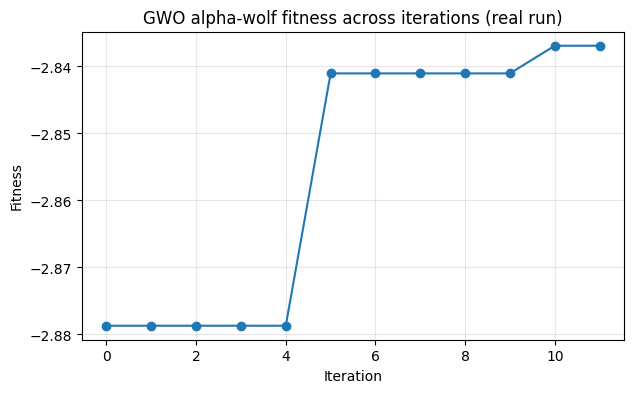

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(sanity_result["gwo_history"], marker="o")
plt.title("GWO alpha-wolf fitness across iterations (real run)")
plt.xlabel("Iteration"); plt.ylabel("Fitness"); plt.grid(alpha=0.3)
plt.show()

## A10. Full 5-seed protocol (as claimed in the paper)

May take hours depending on your hardware (each seed = GWO + training for up
to 30 epochs). Each seed's result is saved immediately to its own JSON file
(`results/results_seed_{seed}.json`) so nothing is lost if execution stops,
and this cell **skips any seed whose output file already exists** instead of
retraining it.

In [11]:
all_results = []
for seed in SEEDS:
    out_path = rpath(f"results_seed_{seed}.json")
    weights_path = rpath(f"scf_weights_seed_{seed}.weights.h5")
    if already_done(out_path):
        print(f"[skip] {out_path} already exists; loading the cached result instead of retraining.")
        res = load_json(out_path)
    else:
        print("\n" + "#" * 70)
        print(f"# SEED = {seed}")
        print("#" * 70)
        res, model = run_once(seed=seed, verbose_gwo=False)
        save_json(res, out_path)
        model.save_weights(weights_path)
        print(f"[saved] {out_path} and {weights_path}")
        del model
        release_memory()
    all_results.append(res)

summary_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ("report_txt", "confusion_matrix", "gwo_history")}
                            for r in all_results])
summary_df.to_csv(rpath("results_summary.csv"), index=False)
print("\n=== Summary across all seeds ===")
print(summary_df)
print("\nMacro-F1 across seeds: mean =", summary_df["macro_f1"].mean(), "+/- std =", summary_df["macro_f1"].std())
print("For per-class detail on rare classes (U2R, BOTNET, ...): inspect results/results_seed_*.json -> report_txt.")


######################################################################
# SEED = 42
######################################################################
GWO done in 4.2s | best-ever fitness = -2.8369 (history: ['-2.879', '-2.879', '-2.879', '-2.879', '-2.879', '-2.841', '-2.841', '-2.841', '-2.841', '-2.841', '-2.837', '-2.837'])

Class weights (Effective-Number, beta=0.999):
    BFA          w=   0.120
    BOTNET       w=   0.691
    DDoS         w=   0.075
    DoS          w=   0.075
    Normal       w=   0.075
    Probe        w=   0.075
    U2R          w=   6.294
    Web-Attack   w=   0.595
    max/min weight ratio = 83.8x (compare to the ~7113x that plain 'balanced' used to produce)
Total parameters: 690,641
Epoch 1/10
1881/1881 - 877s - 466ms/step - accuracy: 0.9509 - loss: 0.0086 - val_accuracy: 0.9640 - val_loss: 0.0082 - learning_rate: 5.0000e-04
Epoch 2/10
1881/1881 - 926s - 492ms/step - accuracy: 0.9712 - loss: 0.0044 - val_accuracy: 0.7572 - val_loss: 0.0213 - learning_r

# Part B: Extended Experiment Suite

Every section below reuses the data (`X_train_r`, `X_val_r`, `X_test_r`,
`Y_tr`, `Y_val`, `Y_te`, `y_train`, `class_names`, `num_classes`, `kept_cols`)
and the helper functions (`evaluate`, `effective_number_weights`,
`weighted_focal_loss`, `AdaptiveChaoticSwish`, `ECABlock`, `rpath`,
`save_json`, `load_json`, `already_done`) defined in Part A above. Run Part A
at least once (real or synthetic) before running any Part B section.

## B0. Shared building blocks for the extended experiment suite

In [15]:
# ----------------------------------------------------------------------
# A configurable model builder used by Sections 1 (baselines), 2 (ablation),
# 3 (activation comparison), 5 (initialization comparison) and 9 (fusion
# ablation). With every flag at its SwarmConvFormer default it reproduces
# EXACTLY the Part A architecture (stem -> [CNN branch, Transformer branch]
# -> fusion -> residual MLP head); each experiment toggles ONLY the one
# thing it studies, holding everything else fixed, so results are directly
# comparable to the main 5-seed SwarmConvFormer numbers instead of
# confounding several changes at once.
# ----------------------------------------------------------------------

class MishActivation(layers.Layer):
    """Mish activation (Misra, 2019): x * tanh(softplus(x)). Not always present
    as a built-in Keras activation, so implemented directly here for the
    activation-function comparison in Section 3."""
    def call(self, x):
        return x * tf.math.tanh(tf.math.softplus(x))


def _make_activation_layer(name, layer_name=None):
    """Returns ONE activation Layer instance for 'acs'/'relu'/'gelu'/'swish'/
    'mish'. Must be called exactly once per use site and then reused (stored
    on `self` inside a custom Layer's build(), or applied immediately when
    building a Functional-API graph) -- NEVER re-instantiated inside a
    Layer's call(), or a stateful activation like AdaptiveChaoticSwish would
    try to create new tf.Variables on every forward pass, which TensorFlow's
    tf.function tracing (used internally by model.fit/predict) rejects with
    'tf.function only supports singleton tf.Variables created on the first
    call'."""
    if name == "acs":
        return AdaptiveChaoticSwish(name=layer_name)
    if name == "relu":
        return layers.Activation("relu", name=layer_name)
    if name == "gelu":
        return layers.Activation("gelu", name=layer_name)
    if name == "swish":
        return layers.Activation("swish", name=layer_name)
    if name == "mish":
        return MishActivation(name=layer_name)
    raise ValueError(f"unknown activation '{name}'")


def _activation_factory(activation_name):
    """Returns act(x, layer_name=None) -> tensor, for use ONLY while building
    a Functional-API graph directly (i.e. plain functions like
    `_resnet1d_block_cfg`/`_transformer_block_cfg`/`_residual_mlp_head_cfg`
    below and `build_configurable_model`'s own body), where each call site
    executes exactly once while the model's graph is being defined -- a
    fresh activation Layer instance is created and immediately applied,
    exactly like the direct `AdaptiveChaoticSwish(name=...)(x)` calls in
    Part A. Do NOT use this inside a custom Layer's call() -- see
    `_make_activation_layer` above and CrossAttentionFusionCfg /
    SymmetricFusion for the correct 'instantiate once in build(), reuse in
    call()' pattern required there."""
    def f(x, name=None):
        return _make_activation_layer(activation_name, name)(x)
    return f


def _resnet1d_block_cfg(x, filters, act, kernel_size=3, stride=1, name="res"):
    shortcut = x
    y = layers.Conv1D(filters, kernel_size, strides=stride, padding="same", use_bias=False, name=f"{name}_conv1")(x)
    y = layers.BatchNormalization(name=f"{name}_bn1")(y)
    y = act(y, name=f"{name}_act1")
    y = layers.Conv1D(filters, kernel_size, strides=1, padding="same", use_bias=False, name=f"{name}_conv2")(y)
    y = layers.BatchNormalization(name=f"{name}_bn2")(y)
    y = ECABlock(kernel_size=3, name=f"{name}_eca")(y)
    if int(shortcut.shape[-1]) != filters or stride != 1:
        shortcut = layers.Conv1D(filters, 1, strides=stride, padding="same", use_bias=False, name=f"{name}_sc")(shortcut)
        shortcut = layers.BatchNormalization(name=f"{name}_sc_bn")(shortcut)
    y = layers.Add(name=f"{name}_add")([y, shortcut])
    return act(y, name=f"{name}_act2")


def _transformer_block_cfg(x, act, num_heads=4, key_dim=32, ff_dim=256, dropout=0.1, name="tr"):
    x_n = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln1")(x)
    a = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim, dropout=dropout, name=f"{name}_mhsa")(x_n, x_n)
    x = layers.Add(name=f"{name}_add1")([x, a])
    x_n2 = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln2")(x)
    f = layers.Dense(ff_dim, name=f"{name}_ff1")(x_n2)
    f = act(f, name=f"{name}_ff_act")
    f = layers.Dropout(dropout, name=f"{name}_ff_drop")(f)
    f = layers.Dense(int(x.shape[-1]), name=f"{name}_ff2")(f)
    return layers.Add(name=f"{name}_add2")([x, f])


def _residual_mlp_head_cfg(x, num_classes, act, hidden=128, dropout=0.3, name="head"):
    x_norm = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln")(x)
    h = layers.Dense(hidden, name=f"{name}_d1")(x_norm)
    h = act(h, name=f"{name}_act1")
    h = layers.Dropout(dropout, name=f"{name}_drop1")(h)
    h = layers.Dense(hidden, name=f"{name}_d2")(h)
    h = act(h, name=f"{name}_act2")
    h = layers.Dropout(dropout, name=f"{name}_drop2")(h)
    x_proj = x_norm if int(x_norm.shape[-1]) == hidden else layers.Dense(hidden, name=f"{name}_proj")(x_norm)
    h = layers.Add(name=f"{name}_add")([h, x_proj])
    return layers.Dense(num_classes, activation="softmax", name=f"{name}_out")(h)


class CrossAttentionFusionCfg(layers.Layer):
    """Same asymmetric cross-attention as Part A's CrossAttentionFusion
    (Q from the CNN branch, K/V from the Transformer branch), with a
    configurable feed-forward activation so Section 3's comparison also
    covers the fusion block's own activation, not only the stem/branches."""
    def __init__(self, dim=128, num_heads=4, dropout=0.1, activation="acs", **kwargs):
        super().__init__(**kwargs)
        self.dim, self.num_heads, self.dropout_rate, self.activation = dim, num_heads, dropout, activation
    def build(self, input_shape):
        self.ln_cnn = layers.LayerNormalization(epsilon=1e-6)
        self.ln_tr = layers.LayerNormalization(epsilon=1e-6)
        self.q_proj = layers.Dense(self.dim, name="cross_q")
        self.k_proj = layers.Dense(self.dim, name="cross_k")
        self.v_proj = layers.Dense(self.dim, name="cross_v")
        self.mha = layers.MultiHeadAttention(num_heads=self.num_heads, key_dim=self.dim // self.num_heads,
                                              dropout=self.dropout_rate, name="cross_mha")
        self.ln_out = layers.LayerNormalization(epsilon=1e-6)
        self.ff1 = layers.Dense(self.dim * 2, name="cross_ff1")
        # instantiated ONCE here (not per call()) -- see _make_activation_layer's docstring
        self.ff_act_layer = _make_activation_layer(self.activation, "cross_ff_act")
        self.ff2 = layers.Dense(self.dim, name="cross_ff2")
        super().build(input_shape)
    def call(self, inputs):
        x_cnn, x_tr = inputs
        q = self.q_proj(self.ln_cnn(x_cnn))
        k = self.k_proj(self.ln_tr(x_tr))
        v = self.v_proj(self.ln_tr(x_tr))
        h = x_cnn + self.mha(query=q, key=k, value=v)
        return h + self.ff2(self.ff_act_layer(self.ff1(self.ln_out(h))))


class SymmetricFusion(layers.Layer):
    """Symmetric counterpart to CrossAttentionFusion, used by Section 9. The
    paper's default fusion is ASYMMETRIC: Q comes only from the CNN branch,
    K/V only from the Transformer branch, so only the CNN representation gets
    updated by attending to the Transformer branch (the Transformer branch is
    never updated by attending back to the CNN branch). This layer implements
    a fair SYMMETRIC alternative: both branches attend to each other (CNN
    queries Transformer AND Transformer queries CNN, each with its own
    MultiHeadAttention), the two attended outputs are summed together with
    both original branch outputs, and the result goes through the same
    feed-forward refinement block as the asymmetric version. The ONLY
    architectural difference from CrossAttentionFusion is therefore which
    branch(es) get to query the other one -- dimensions, head count, FF
    width, activation and dropout are all held identical, for a fair,
    single-factor comparison."""
    def __init__(self, dim=128, num_heads=4, dropout=0.1, activation="acs", **kwargs):
        super().__init__(**kwargs)
        self.dim, self.num_heads, self.dropout_rate, self.activation = dim, num_heads, dropout, activation
    def build(self, input_shape):
        self.ln_cnn = layers.LayerNormalization(epsilon=1e-6)
        self.ln_tr = layers.LayerNormalization(epsilon=1e-6)
        self.q_c = layers.Dense(self.dim, name="sym_q_c")
        self.k_c = layers.Dense(self.dim, name="sym_k_c")
        self.v_c = layers.Dense(self.dim, name="sym_v_c")
        self.q_t = layers.Dense(self.dim, name="sym_q_t")
        self.k_t = layers.Dense(self.dim, name="sym_k_t")
        self.v_t = layers.Dense(self.dim, name="sym_v_t")
        self.mha_c2t = layers.MultiHeadAttention(num_heads=self.num_heads, key_dim=self.dim // self.num_heads,
                                                  dropout=self.dropout_rate, name="sym_mha_c2t")
        self.mha_t2c = layers.MultiHeadAttention(num_heads=self.num_heads, key_dim=self.dim // self.num_heads,
                                                  dropout=self.dropout_rate, name="sym_mha_t2c")
        self.ln_out = layers.LayerNormalization(epsilon=1e-6)
        self.ff1 = layers.Dense(self.dim * 2, name="sym_ff1")
        # instantiated ONCE here (not per call()) -- see _make_activation_layer's docstring
        self.ff_act_layer = _make_activation_layer(self.activation, "sym_ff_act")
        self.ff2 = layers.Dense(self.dim, name="sym_ff2")
        super().build(input_shape)
    def call(self, inputs):
        x_cnn, x_tr = inputs
        cn = self.ln_cnn(x_cnn)
        tn = self.ln_tr(x_tr)
        c2t = self.mha_c2t(query=self.q_c(cn), key=self.k_t(tn), value=self.v_t(tn))
        t2c = self.mha_t2c(query=self.q_t(tn), key=self.k_c(cn), value=self.v_c(cn))
        h = x_cnn + x_tr + c2t + t2c
        return h + self.ff2(self.ff_act_layer(self.ff1(self.ln_out(h))))


def build_configurable_model(input_dim, num_classes,
                              use_cnn_branch=True, use_transformer_branch=True,
                              activation="acs", init_strategy="gwo", gwo_kernel=None,
                              fusion="cross_attention",
                              stem_filters=64, filters_mult=1.0,
                              num_transformer_blocks=2, ff_dim=256,
                              tr_heads=4, tr_key_dim=32):
    """General model builder for Sections 1, 2, 3, 5 and 9.

    use_cnn_branch / use_transformer_branch: exactly one False reproduces the
        '1D-CNN' / 'Transformer-Only' baselines from Section 1.
    activation: 'acs' (paper default), 'relu', 'gelu', 'swish', 'mish'.
    init_strategy: 'gwo' (needs gwo_kernel), 'he', 'glorot', 'lecun' -- applies
        to the stem convolution's kernel initializer only.
    fusion: 'cross_attention' (paper default), 'additive' (plain element-wise
        sum, used by the CT / CT+Focal baselines and the no-cross-attention
        ablation), 'symmetric' (Section 9).
    filters_mult / ff_dim / num_transformer_blocks: sizing knobs used to hit
        specific parameter-count targets (Section 1's parameter-matched
        baselines); leave at their SwarmConvFormer defaults (1.0 / 256 / 2)
        everywhere else.
    """
    if not use_cnn_branch and not use_transformer_branch:
        raise ValueError("at least one branch must be enabled")

    act = _activation_factory(activation)
    if init_strategy == "gwo":
        if gwo_kernel is None:
            raise ValueError("gwo_kernel is required when init_strategy='gwo'")
        stem_init = GWOKernelInitializer(gwo_kernel)
    elif init_strategy == "he":
        stem_init = "he_normal"
    elif init_strategy == "glorot":
        stem_init = "glorot_uniform"
    elif init_strategy == "lecun":
        stem_init = "lecun_normal"
    else:
        raise ValueError(f"unknown init_strategy '{init_strategy}'")

    inputs = Input(shape=(input_dim, 1), name="input")
    x = layers.Conv1D(stem_filters, kernel_size=7, padding="same",
                       kernel_initializer=stem_init, use_bias=False, name="stem_conv")(inputs)
    x = layers.BatchNormalization(name="stem_bn")(x)
    x = act(x, name="stem_act")

    f1, f2, f3 = int(64 * filters_mult), int(96 * filters_mult), int(128 * filters_mult)
    c = t = None
    if use_cnn_branch:
        c = _resnet1d_block_cfg(x, f1, act, name="res1")
        c = _resnet1d_block_cfg(c, f2, act, stride=2, name="res2")
        c = _resnet1d_block_cfg(c, f3, act, name="res3")
    if use_transformer_branch:
        t = layers.Conv1D(128, 3, padding="same", name="tr_local_conv")(x)
        t = act(t, name="tr_local_act")
        t = layers.AveragePooling1D(pool_size=2, name="tr_pool")(t)
        for i in range(num_transformer_blocks):
            t = _transformer_block_cfg(t, act, num_heads=tr_heads, key_dim=tr_key_dim,
                                        ff_dim=ff_dim, dropout=0.1, name=f"tr{i+1}")

    if use_cnn_branch and use_transformer_branch:
        if fusion == "cross_attention":
            fused = CrossAttentionFusionCfg(dim=128, num_heads=4, dropout=0.1,
                                             activation=activation, name="xattn_fuse")([c, t])
        elif fusion in ("symmetric", "additive"):
            # both 'symmetric' and 'additive' fusion sum the two branches
            # elementwise at some point (unlike cross-attention, whose
            # MultiHeadAttention output shape follows the query and so
            # tolerates a query/key-value length mismatch on its own). Both
            # branches apply exactly one stride-2 / pool-2 downsampling step,
            # so their sequence lengths normally match; crop defensively in
            # case 'same' padding rounds an odd input length differently
            # between the two branches (observed on the T=65 real feature
            # count: CNN branch length 33 vs. Transformer branch length 32).
            Lc, Lt = int(c.shape[1]), int(t.shape[1])
            if Lc != Lt:
                m = min(Lc, Lt)
                if Lc > m:
                    c = layers.Cropping1D((0, Lc - m), name="fuse_crop_c")(c)
                if Lt > m:
                    t = layers.Cropping1D((0, Lt - m), name="fuse_crop_t")(t)
            if fusion == "additive":
                fused = layers.Add(name="fuse_add")([c, t])
            else:
                fused = SymmetricFusion(dim=128, num_heads=4, dropout=0.1,
                                         activation=activation, name="sym_fuse")([c, t])
        else:
            raise ValueError(f"unknown fusion '{fusion}'")
    elif use_cnn_branch:
        fused = c
    else:
        fused = t

    pooled = layers.GlobalAveragePooling1D(name="gap")(fused)
    outputs = _residual_mlp_head_cfg(pooled, num_classes, act, hidden=128)
    return Model(inputs, outputs, name="ConfigurableSCFVariant")


def build_mlp_baseline(input_dim, num_classes, hidden_layers=(512, 768, 256, 128), dropout=0.3):
    """4-layer MLP baseline (Section 1, Table 3): plain ReLU + He init +
    dropout, sized to land within +/-5% of SwarmConvFormer's 690,641
    parameters at T=65 features / 8 classes. Trained with plain
    (unweighted) categorical cross-entropy, per the Table 3 protocol."""
    inputs = Input(shape=(input_dim,), name="input")
    x = inputs
    for i, h in enumerate(hidden_layers):
        x = layers.Dense(h, kernel_initializer="he_normal", name=f"mlp_d{i+1}")(x)
        x = layers.Activation("relu", name=f"mlp_act{i+1}")(x)
        x = layers.Dropout(dropout, name=f"mlp_drop{i+1}")(x)
    outputs = layers.Dense(num_classes, activation="softmax", kernel_initializer="he_normal", name="mlp_out")(x)
    return Model(inputs, outputs, name="MLP-Baseline")


def check_param_match(model, target=690641, tol=0.05, label=""):
    n = model.count_params()
    delta = (n - target) / target
    ok = abs(delta) <= tol
    print(f"[param-match check]{(' ' + label) if label else ''}: n_params={n:,}  "
          f"target={target:,}  delta={delta*100:+.1f}%  within +/-{tol*100:.0f}%: {ok}")
    return ok


def train_and_evaluate(model, loss, seed, lr=BASELINE_LR, epochs=None, batch_size=BATCH_SIZE,
                        es_patience=BASELINE_ES_PATIENCE, rlrop_patience=BASELINE_RLROP_PATIENCE,
                        rlrop_factor=BASELINE_RLROP_FACTOR, X_tr_input=None, X_val_input=None,
                        X_te_input=None, class_weight=None, verbose=2):
    """Shared training+evaluation helper for Sections 1, 2, 3, 5 and 9, so
    each experiment reuses ONE consistent training loop (compile, callbacks,
    fit, evaluate) instead of duplicating boilerplate. Uses the SAME 70/10/20
    split and data pipeline as the main SwarmConvFormer protocol; only the
    model, the loss, the optimizer budget and (optionally) `class_weight`
    vary per experiment. `X_tr_input`/`X_val_input`/`X_te_input` default to
    the 3D conv-ready arrays (X_train_r/X_val_r/X_test_r); pass the 2D
    X_train/X_val/X_test arrays instead for the flat MLP baseline."""
    if epochs is None:
        epochs = BASELINE_EPOCHS
    X_tr_input = X_train_r if X_tr_input is None else X_tr_input
    X_val_input = X_val_r if X_val_input is None else X_val_input
    X_te_input = X_test_r if X_te_input is None else X_te_input

    model.compile(optimizer=Adam(learning_rate=lr, clipnorm=1.0), loss=loss, metrics=["accuracy"])
    callbacks = [
        EarlyStopping(monitor="val_loss", mode="min", patience=es_patience, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", mode="min", factor=rlrop_factor, patience=rlrop_patience,
                           min_lr=1e-6, verbose=0),
    ]
    t0 = time.time()
    history = model.fit(X_tr_input, Y_tr, validation_data=(X_val_input, Y_val), epochs=epochs,
                         batch_size=batch_size, callbacks=callbacks, class_weight=class_weight, verbose=verbose)
    train_time = time.time() - t0
    results = evaluate(model, X_te_input, Y_te, class_names=class_names)
    results.update({"seed": seed, "train_time_s": train_time, "epochs_ran": len(history.history["loss"]),
                     "n_params": model.count_params()})
    return results, model


def load_scf_model(seed, input_dim=None):
    """Reconstructs the SwarmConvFormer architecture (He-initialized stem
    PLACEHOLDER -- only trained WEIGHTS are restored here, the GWO
    initializer itself is irrelevant once training is finished) and loads
    the weights saved for `seed` by Part A's 5-seed loop. Used by Sections 4
    (permutation importance), 6 (latency/quantization) and 8 (filter
    orthogonality) so they never need to keep 5 seeds' models resident in
    memory or re-run GWO + training just to analyze an already-trained model."""
    if input_dim is None:
        input_dim = X_train_r.shape[1]
    m = build_hybrid_model(input_shape=(input_dim, 1), num_classes=num_classes,
                            gwo_kernel=None, stem_filters=64, num_transformer_blocks=2)
    m.load_weights(rpath(f"scf_weights_seed_{seed}.weights.h5"))
    return m


print("Part B shared helpers loaded.")
print("Sanity check: build_configurable_model with paper defaults should match")
print("the Part A SwarmConvFormer's parameter count.")
_probe_kernel = np.zeros((7, 1, 64), dtype=np.float32)
_probe_model = build_configurable_model(X_train_r.shape[1], num_classes, gwo_kernel=_probe_kernel)
check_param_match(_probe_model, target=sanity_model.count_params(), tol=0.001,
                   label="build_configurable_model defaults vs. Part A SwarmConvFormer")
del _probe_model, _probe_kernel

Part B shared helpers loaded.
Sanity check: build_configurable_model with paper defaults should match
the Part A SwarmConvFormer's parameter count.
[param-match check] build_configurable_model defaults vs. Part A SwarmConvFormer: n_params=690,641  target=690,641  delta=+0.0%  within +/-0%: True


## Section 1: Parameter-matched baseline models (Table 3)

Five baselines, each sized to land within +/-5% of SwarmConvFormer's
690,641 parameters (at T=65 features, 8 classes -- the actual parameter
count depends on the real T your data produces in Part A, so a check is
printed for each model): `MLP-Baseline`, `1D-CNN`, `Transformer-Only`, `CT`
(vanilla Conv-Transformer hybrid, He init, ReLU, additive fusion) and
`CT+Focal` (same as CT but with the focal loss). All five use the SAME data
pipeline, SAME 70/10/20 split, SAME 5 seeds and the SAME optimization budget
(Adam lr=0.001, batch=128, up to 30 epochs, ReduceLROnPlateau patience=4
factor=0.5, EarlyStopping patience=8 on val_loss) -- the paper's Section 4.3
baseline budget, deliberately NOT SwarmConvFormer's own lr=5e-4.

Loss convention used here (documented judgment call): `MLP-Baseline`,
`1D-CNN`, `Transformer-Only` and `CT` all use plain, UNWEIGHTED categorical
cross-entropy; only `CT+Focal` switches to the SAME class-weighted focal
loss used by SwarmConvFormer. This mirrors the naming ("CT+Focal" = CT plus
focal loss) and lets Table 3 show the incremental effect of each SCF
ingredient (focal loss here, then GWO/ACS/cross-attention in the main
result and in Section 2's ablation) rather than mixing several changes into
one baseline.

Output files: `results/baseline_{model_name}_seed_{seed}.json` (same schema
as `results_seed_*.json`: accuracy, macro_precision, macro_recall, macro_f1,
mcc, report_txt, confusion_matrix, seed, train_time_s, epochs_ran) and a
final `results/baselines_summary.csv` (model x seed x metrics, plus
mean+/-std per model) for Table 3.

In [16]:
BASELINE_SPECS = {
    # name -> dict of build kwargs / loss choice. filters_mult / ff_dim /
    # num_transformer_blocks were tuned offline (see the model card printed
    # below) so each architecture lands within +/-5% of 690,641 params at
    # T=65 / 8 classes.
    "MLP-Baseline":      dict(kind="mlp"),
    "1D-CNN":            dict(kind="cnn", activation="relu", init_strategy="he",
                               filters_mult=1.85, use_transformer_branch=False),
    "Transformer-Only":  dict(kind="cnn", activation="gelu", init_strategy="he",
                               ff_dim=560, num_transformer_blocks=3, use_cnn_branch=False),
    "CT":                dict(kind="cnn", activation="relu", init_strategy="he",
                               fusion="additive", ff_dim=320, num_transformer_blocks=3),
    "CT+Focal":          dict(kind="cnn", activation="relu", init_strategy="he",
                               fusion="additive", ff_dim=320, num_transformer_blocks=3, use_focal=True),
}


def build_baseline_model(name, input_dim, num_classes):
    spec = BASELINE_SPECS[name]
    if spec["kind"] == "mlp":
        return build_mlp_baseline(input_dim, num_classes)
    kwargs = {k: v for k, v in spec.items() if k not in ("kind", "use_focal")}
    return build_configurable_model(input_dim, num_classes, **kwargs)


def run_baseline(name, seed):
    np.random.seed(seed); tf.random.set_seed(seed); random.seed(seed)
    model = build_baseline_model(name, X_train_r.shape[1], num_classes)
    use_focal = BASELINE_SPECS[name].get("use_focal", False)
    is_mlp = BASELINE_SPECS[name]["kind"] == "mlp"
    if use_focal:
        class_weights = effective_number_weights(y_train, num_classes, beta=WEIGHT_BETA)
        loss = weighted_focal_loss(class_weights, gamma=2.0)
    else:
        loss = CategoricalCrossentropy()
    X_tr_in = X_train if is_mlp else X_train_r
    X_val_in = X_val if is_mlp else X_val_r
    X_te_in = X_test if is_mlp else X_test_r
    results, _ = train_and_evaluate(model, loss, seed, lr=BASELINE_LR, epochs=BASELINE_EPOCHS,
                                     X_tr_input=X_tr_in, X_val_input=X_val_in, X_te_input=X_te_in)
    results["model_name"] = name
    return results


print("Baseline model cards (parameter-match check at the real T from Part A):")
for name in BASELINE_SPECS:
    m = build_baseline_model(name, X_train_r.shape[1], num_classes)
    check_param_match(m, target=690641, tol=0.05, label=name)
    del m
release_memory()

Baseline model cards (parameter-match check at the real T from Part A):
[param-match check] MLP-Baseline: n_params=658,568  target=690,641  delta=-4.6%  within +/-5%: True
[param-match check] 1D-CNN: n_params=669,460  target=690,641  delta=-3.1%  within +/-5%: True
[param-match check] Transformer-Only: n_params=691,544  target=690,641  delta=+0.1%  within +/-5%: True
[param-match check] CT: n_params=684,817  target=690,641  delta=-0.8%  within +/-5%: True
[param-match check] CT+Focal: n_params=684,817  target=690,641  delta=-0.8%  within +/-5%: True


In [ ]:
baseline_all_results = []
for name in BASELINE_SPECS:
    for seed in SEEDS:
        out_path = rpath(f"baseline_{name}_seed_{seed}.json")
        if already_done(out_path):
            print(f"[skip] {out_path} already exists.")
            res = load_json(out_path)
        else:
            print(f"\n[baseline] model={name} seed={seed}")
            res = run_baseline(name, seed)
            save_json(res, out_path)
            print(f"[saved] {out_path}")
            release_memory()
        baseline_all_results.append(res)

baselines_summary_rows = [{k: v for k, v in r.items() if k not in ("report_txt", "confusion_matrix")}
                           for r in baseline_all_results]
baselines_df = pd.DataFrame(baselines_summary_rows)
agg = baselines_df.groupby("model_name")[["accuracy", "macro_precision", "macro_recall", "macro_f1", "mcc"]] \
                   .agg(["mean", "std"])
agg.columns = ["_".join(c) for c in agg.columns]
agg = agg.reset_index()
baselines_df.to_csv(rpath("baselines_per_seed.csv"), index=False)
agg.to_csv(rpath("baselines_summary.csv"), index=False)
print("\n=== Table 3 baseline summary (mean +/- std across seeds) ===")
print(agg[["model_name", "macro_f1_mean", "macro_f1_std", "accuracy_mean", "accuracy_std", "mcc_mean", "mcc_std"]])


[baseline] model=MLP-Baseline seed=42
Epoch 1/30
1881/1881 - 37s - 20ms/step - accuracy: 0.9684 - loss: 0.1083 - val_accuracy: 0.9827 - val_loss: 0.0537 - learning_rate: 0.0010
Epoch 2/30
1881/1881 - 29s - 15ms/step - accuracy: 0.9820 - loss: 0.0609 - val_accuracy: 0.9851 - val_loss: 0.0460 - learning_rate: 0.0010
Epoch 3/30
1881/1881 - 42s - 22ms/step - accuracy: 0.9852 - loss: 0.0549 - val_accuracy: 0.9866 - val_loss: 0.0428 - learning_rate: 0.0010
Epoch 4/30
1881/1881 - 29s - 16ms/step - accuracy: 0.9869 - loss: 0.0437 - val_accuracy: 0.9864 - val_loss: 0.0359 - learning_rate: 0.0010
Epoch 5/30
1881/1881 - 41s - 22ms/step - accuracy: 0.9916 - loss: 0.0485 - val_accuracy: 0.9946 - val_loss: 0.0233 - learning_rate: 0.0010
Epoch 6/30
1881/1881 - 30s - 16ms/step - accuracy: 0.9925 - loss: 0.0303 - val_accuracy: 0.9942 - val_loss: 0.0231 - learning_rate: 0.0010
Epoch 7/30
1881/1881 - 30s - 16ms/step - accuracy: 0.9935 - loss: 0.0312 - val_accuracy: 0.9958 - val_loss: 0.0158 - learning_r

## Section 2: Ablation study (Table 5)

Leave-one-out ablation over SwarmConvFormer's four novel ingredients:
GWO-initialized stem (vs. He init), ACS activation (vs. plain ReLU),
asymmetric cross-attention fusion (vs. simple additive fusion), and focal
loss (vs. plain weighted cross-entropy). Five configurations, each run
across the 5 seeds: `full` (reuses the main 5-seed SwarmConvFormer result
from Part A -- it IS the full model, no need to retrain it) plus four
single-component removals.

Output files: `results/ablation_{config_name}_seed_{seed}.json` per run, and
`results/ablation_summary.csv` (config x seed x macro_f1/accuracy/mcc,
mean+/-std per config, and the macro-F1 delta vs. the full model).

In [22]:
from dataclasses import dataclass, asdict

@dataclass
class AblationConfig:
    name: str
    use_gwo: bool = True
    use_acs: bool = True
    use_cross_attention: bool = True
    use_focal: bool = True

ABLATION_GRID = [
    AblationConfig("full"),
    AblationConfig("no_gwo", use_gwo=False),
    AblationConfig("no_acs", use_acs=False),
    AblationConfig("no_cross_attention", use_cross_attention=False),
    AblationConfig("no_focal", use_focal=False),
]


def run_ablation(cfg: AblationConfig, seed):
    """Builds and trains one ablation configuration for one seed. 'full' is
    handled by the caller (reused from Part A's results_seed_*.json) and
    never reaches this function."""
    np.random.seed(seed); tf.random.set_seed(seed); random.seed(seed)

    gwo_kernel = None
    gwo_time = 0.0
    if cfg.use_gwo:
        probe_idx = np.random.choice(len(X_train_r), size=min(256, len(X_train_r)), replace=False)
        probe = tf.constant(X_train_r[probe_idx], dtype=tf.float32)
        gwo = GreyWolfOptimizer(n_wolves=GWO_WOLVES, n_iterations=GWO_ITERATIONS,
                                 kernel_shape=(7, 1, 64), sample_input=probe, verbose=False)
        t0 = time.time()
        gwo_kernel = gwo.optimize()
        gwo_time = time.time() - t0

    model = build_configurable_model(
        X_train_r.shape[1], num_classes,
        activation="acs" if cfg.use_acs else "relu",
        init_strategy="gwo" if cfg.use_gwo else "he",
        gwo_kernel=gwo_kernel,
        fusion="cross_attention" if cfg.use_cross_attention else "additive",
    )

    class_weights = effective_number_weights(y_train, num_classes, beta=WEIGHT_BETA)
    if cfg.use_focal:
        loss = weighted_focal_loss(class_weights, gamma=2.0)
        class_weight_arg = None
    else:
        # "plain weighted cross-entropy": same Effective-Number weights, but
        # via Keras' class_weight mechanism instead of the focal modulation.
        loss = CategoricalCrossentropy()
        class_weight_arg = {i: float(w) for i, w in enumerate(class_weights)}

    results, _ = train_and_evaluate(model, loss, seed, lr=LEARNING_RATE, epochs=EPOCHS,
                                     class_weight=class_weight_arg)
    results["config_name"] = cfg.name
    results["gwo_time_s"] = gwo_time
    return results

In [23]:
ablation_all_results = []
for cfg in ABLATION_GRID:
    for seed in SEEDS:
        out_path = rpath(f"ablation_{cfg.name}_seed_{seed}.json")
        if cfg.name == "full":
            # the full config IS the main SwarmConvFormer run from Part A;
            # reuse it instead of retraining an identical model.
            main_path = rpath(f"results_seed_{seed}.json")
            if already_done(out_path):
                res = load_json(out_path)
            elif already_done(main_path):
                res = load_json(main_path)
                res = dict(res)
                res["config_name"] = "full"
                save_json(res, out_path)
                print(f"[reused] {main_path} -> {out_path}")
            else:
                raise RuntimeError("Run Part A's 5-seed loop before Section 2 (need the 'full' result).")
        elif already_done(out_path):
            print(f"[skip] {out_path} already exists.")
            res = load_json(out_path)
        else:
            print(f"\n[ablation] config={cfg.name} seed={seed}")
            res = run_ablation(cfg, seed)
            save_json(res, out_path)
            print(f"[saved] {out_path}")
            release_memory()
        ablation_all_results.append(res)

ablation_rows = [{k: v for k, v in r.items() if k not in ("report_txt", "confusion_matrix", "gwo_history")}
                  for r in ablation_all_results]
ablation_df = pd.DataFrame(ablation_rows)
ablation_agg = ablation_df.groupby("config_name")[["accuracy", "macro_f1", "mcc"]].agg(["mean", "std"])
ablation_agg.columns = ["_".join(c) for c in ablation_agg.columns]
ablation_agg = ablation_agg.reset_index()

full_f1 = ablation_agg.loc[ablation_agg["config_name"] == "full", "macro_f1_mean"].iloc[0]
ablation_agg["macro_f1_delta_vs_full"] = ablation_agg["macro_f1_mean"] - full_f1

ablation_df.to_csv(rpath("ablation_per_seed.csv"), index=False)
ablation_agg.to_csv(rpath("ablation_summary.csv"), index=False)
print("\n=== Table 5 ablation summary (mean +/- std across seeds, delta vs. full) ===")
print(ablation_agg)

[reused] results\results_seed_42.json -> results\ablation_full_seed_42.json
[reused] results\results_seed_123.json -> results\ablation_full_seed_123.json

[ablation] config=no_gwo seed=42
Epoch 1/3
33/33 - 207s - 6s/step - accuracy: 0.8676 - loss: 0.0592 - val_accuracy: 0.8317 - val_loss: 0.0557 - learning_rate: 5.0000e-04
Epoch 2/3
33/33 - 32s - 966ms/step - accuracy: 0.9671 - loss: 0.0100 - val_accuracy: 0.9167 - val_loss: 0.0704 - learning_rate: 5.0000e-04
Epoch 3/3
33/33 - 42s - 1s/step - accuracy: 0.9655 - loss: 0.0075 - val_accuracy: 0.9417 - val_loss: 0.0672 - learning_rate: 5.0000e-04
  Accuracy        : 0.8375
  Macro Precision : 0.7615
  Macro Recall    : 0.7427
  Macro F1        : 0.7428
  MCC             : 0.7962
              precision    recall  f1-score   support

         BFA     0.8696    0.9836    0.9231        61
      BOTNET     0.9444    0.9444    0.9444        18
        DDoS     1.0000    0.8807    0.9365       243
         DoS     0.8556    0.5083    0.6377     

## Section 3: Activation function comparison, single consistent dead-zone method (Table 5b)

Applies ONE well-documented dead-zone measurement, `compute_dead_zone_ratio`,
to models trained with ReLU, GELU, Swish, Mish and ACS, otherwise identical
architecture and training budget to the `CT+Focal` baseline from Section 1
(He init, additive fusion, focal loss; only the activation family varies).
This replaces the two inconsistent dead-zone measurements used earlier in
this project (which reported 84.50% vs. 97.72% for ReLU and 2.90% vs. 8.17%
for ACS on the same model, because they measured different things).

Output files: `results/activation_{name}_seed_{seed}.json` (macro_f1,
accuracy, dead_zone_ratio) and `results/activation_summary.csv`.

In [24]:
def compute_dead_zone_ratio(model, layer_name, val_data, threshold=1e-3):
    """Single, consistent dead-zone measurement (Section 3 / Table 5b).

    Method chosen (documented, single source of truth): forward-pass OUTPUT
    MAGNITUDE thresholding on one FIXED validation batch. We build a Keras
    sub-model up to `layer_name`'s output, run the fixed batch through it
    once, and report the fraction of individual activation scalars whose
    absolute value falls below `threshold`.

    Why output magnitude rather than gradients: (a) it needs only a forward
    pass, so it is cheap and fully deterministic given a fixed batch and a
    fixed threshold -- no dependence on which loss/backward graph is used;
    (b) it applies the same way to every activation family compared here
    (ReLU/GELU/Swish/Mish/ACS) without needing a task loss or a backward
    pass, whereas a gradient-based measure would need care to stay
    comparable across activations with very different gradient shapes
    (e.g. ACS's chaotic sine term vs. ReLU's flat zero-gradient region);
    (c) it matches the intuitive definition of a 'dead' unit as one that
    outputs (near-)zero and therefore carries no information forward to the
    next layer, regardless of why its gradient happens to be small or large.
    This is the ONLY dead-zone method used anywhere in this notebook."""
    sub_model = Model(inputs=model.input, outputs=model.get_layer(layer_name).output)
    out = sub_model.predict(val_data, verbose=0)
    dead = np.abs(out) < threshold
    return float(dead.mean() * 100.0)


ACTIVATION_VARIANTS = ["relu", "gelu", "swish", "mish", "acs"]
# fixed, large validation batch reused for every activation/seed so results
# are directly comparable to one another.
DEAD_ZONE_PROBE = X_val_r[:min(1024, len(X_val_r))]
DEAD_ZONE_LAYER = "stem_act"
DEAD_ZONE_THRESHOLD = 1e-3


def run_activation_variant(name, seed):
    np.random.seed(seed); tf.random.set_seed(seed); random.seed(seed)
    model = build_configurable_model(
        X_train_r.shape[1], num_classes, activation=name, init_strategy="he",
        fusion="additive", ff_dim=320, num_transformer_blocks=3,
    )
    class_weights = effective_number_weights(y_train, num_classes, beta=WEIGHT_BETA)
    loss = weighted_focal_loss(class_weights, gamma=2.0)
    results, trained_model = train_and_evaluate(model, loss, seed, lr=BASELINE_LR, epochs=BASELINE_EPOCHS)
    results["activation"] = name
    results["dead_zone_layer"] = DEAD_ZONE_LAYER
    results["dead_zone_threshold"] = DEAD_ZONE_THRESHOLD
    results["dead_zone_ratio"] = compute_dead_zone_ratio(trained_model, DEAD_ZONE_LAYER,
                                                           DEAD_ZONE_PROBE, DEAD_ZONE_THRESHOLD)
    return results

In [25]:
activation_all_results = []
for name in ACTIVATION_VARIANTS:
    for seed in SEEDS:
        out_path = rpath(f"activation_{name}_seed_{seed}.json")
        if already_done(out_path):
            print(f"[skip] {out_path} already exists.")
            res = load_json(out_path)
        else:
            print(f"\n[activation] variant={name} seed={seed}")
            res = run_activation_variant(name, seed)
            save_json(res, out_path)
            print(f"[saved] {out_path}  dead_zone_ratio={res['dead_zone_ratio']:.2f}%")
            release_memory()
        activation_all_results.append(res)

activation_rows = [{k: v for k, v in r.items() if k not in ("report_txt", "confusion_matrix")}
                    for r in activation_all_results]
activation_df = pd.DataFrame(activation_rows)
activation_agg = activation_df.groupby("activation")[["accuracy", "macro_f1", "dead_zone_ratio"]].agg(["mean", "std"])
activation_agg.columns = ["_".join(c) for c in activation_agg.columns]
activation_agg = activation_agg.reset_index()

activation_df.to_csv(rpath("activation_per_seed.csv"), index=False)
activation_agg.to_csv(rpath("activation_summary.csv"), index=False)
print("\n=== Table 5b activation comparison (mean +/- std across seeds) ===")
print(activation_agg)


[activation] variant=relu seed=42
Epoch 1/3
33/33 - 154s - 5s/step - accuracy: 0.7082 - loss: 0.1533 - val_accuracy: 0.7583 - val_loss: 0.0525 - learning_rate: 0.0010
Epoch 2/3
33/33 - 32s - 969ms/step - accuracy: 0.9164 - loss: 0.0238 - val_accuracy: 0.7850 - val_loss: 0.0849 - learning_rate: 0.0010
Epoch 3/3
33/33 - 41s - 1s/step - accuracy: 0.9409 - loss: 0.0190 - val_accuracy: 0.9183 - val_loss: 0.0198 - learning_rate: 0.0010
  Accuracy        : 0.9042
  Macro Precision : 0.8527
  Macro Recall    : 0.8601
  Macro F1        : 0.8156
  MCC             : 0.8746
              precision    recall  f1-score   support

         BFA     1.0000    0.3443    0.5122        61
      BOTNET     1.0000    0.8333    0.9091        18
        DDoS     0.9682    0.8765    0.9201       243
         DoS     0.8993    0.8845    0.8918       303
      Normal     0.9237    1.0000    0.9604       424
       Probe     0.9500    0.9421    0.9461       121
         U2R     0.6667    1.0000    0.8000        

## Section 4: Feature-permutation importance (Table 5c)

Standard permutation importance, per individual feature (T features, the
same `kept_cols` produced by Part A's `select_informative_features`), using
the already-trained SwarmConvFormer models (5 seeds, reloaded via
`load_scf_model` -- no new training). For each feature, its column is
shuffled in the held-out test set, macro-F1 is re-computed, and the drop
versus the unpermuted baseline is recorded; this is repeated
`PERMUTATION_REPEATS` times per feature to average out shuffling noise, and
across all 5 seeds.

Output files: `results/permutation_importance_seed_{seed}.json` (per-feature
macro_f1 drop) and `results/permutation_importance_summary.csv` (feature x
mean/std drop across seeds, sorted most-to-least important).

In [26]:
def permutation_importance_for_seed(seed, repeats=PERMUTATION_REPEATS, rng_seed=0,
                                     max_features=PERMUTATION_MAX_FEATURES):
    model = load_scf_model(seed, input_dim=X_test_r.shape[1])
    baseline_metrics = evaluate(model, X_test_r, Y_te, class_names=class_names)
    baseline_f1 = baseline_metrics["macro_f1"]
    y_true = np.argmax(Y_te, axis=1)

    n_features = X_test_r.shape[1]
    feature_ids = list(range(n_features)) if max_features is None else list(range(min(max_features, n_features)))
    rng = np.random.default_rng(rng_seed)

    feature_importance = {}
    for fi in feature_ids:
        fname = kept_cols[fi] if fi < len(kept_cols) else f"feature_{fi}"
        f1_scores = []
        for _ in range(repeats):
            X_perm = X_test_r.copy()
            perm_idx = rng.permutation(X_perm.shape[0])
            X_perm[:, fi, 0] = X_perm[perm_idx, fi, 0]
            y_proba = model.predict(X_perm, verbose=0)
            y_hat = np.argmax(y_proba, axis=1)
            f1_scores.append(f1_score(y_true, y_hat, average="macro", zero_division=0))
        mean_f1 = float(np.mean(f1_scores))
        feature_importance[fname] = {
            "permuted_macro_f1_mean": mean_f1,
            "permuted_macro_f1_std": float(np.std(f1_scores)),
            "macro_f1_drop": baseline_f1 - mean_f1,
        }

    return {"seed": seed, "baseline_macro_f1": baseline_f1,
            "n_features_evaluated": len(feature_ids), "repeats": repeats,
            "feature_importance": feature_importance}

In [27]:
permutation_all_results = []
for seed in SEEDS:
    out_path = rpath(f"permutation_importance_seed_{seed}.json")
    if already_done(out_path):
        print(f"[skip] {out_path} already exists.")
        res = load_json(out_path)
    else:
        print(f"\n[permutation importance] seed={seed}")
        res = permutation_importance_for_seed(seed)
        save_json(res, out_path)
        print(f"[saved] {out_path}  baseline_macro_f1={res['baseline_macro_f1']:.4f}")
        release_memory()
    permutation_all_results.append(res)

perm_rows = []
for res in permutation_all_results:
    for fname, stats in res["feature_importance"].items():
        perm_rows.append({"seed": res["seed"], "feature": fname, **stats})
perm_df = pd.DataFrame(perm_rows)
perm_agg = perm_df.groupby("feature")["macro_f1_drop"].agg(["mean", "std"]).reset_index()
perm_agg = perm_agg.rename(columns={"mean": "macro_f1_drop_mean", "std": "macro_f1_drop_std"})
perm_agg = perm_agg.sort_values("macro_f1_drop_mean", ascending=False)

perm_df.to_csv(rpath("permutation_importance_per_seed.csv"), index=False)
perm_agg.to_csv(rpath("permutation_importance_summary.csv"), index=False)
print("\n=== Table 5c permutation importance (top 15 features by mean macro-F1 drop) ===")
print(perm_agg.head(15))


[permutation importance] seed=42
  Accuracy        : 0.8675
  Macro Precision : 0.4925
  Macro Recall    : 0.5098
  Macro F1        : 0.4969
  MCC             : 0.8266
              precision    recall  f1-score   support

         BFA     0.3585    0.3115    0.3333        61
      BOTNET     0.0000    0.0000    0.0000        18
        DDoS     0.9916    0.9712    0.9813       243
         DoS     0.9718    0.7954    0.8748       303
      Normal     0.8760    1.0000    0.9339       424
       Probe     0.7423    1.0000    0.8521       121
         U2R     0.0000    0.0000    0.0000         6
  Web-Attack     0.0000    0.0000    0.0000        24

    accuracy                         0.8675      1200
   macro avg     0.4925    0.5098    0.4969      1200
weighted avg     0.8488    0.8675    0.8524      1200

[saved] results\permutation_importance_seed_42.json  baseline_macro_f1=0.4969

[permutation importance] seed=123
  Accuracy        : 0.8442
  Macro Precision : 0.5814
  Macro Recal

## Section 5: Initialization strategy comparison (Table 5d)

Retrains the full SwarmConvFormer topology (ACS, cross-attention, focal
loss all ON) with four different stem kernel initializers: Glorot, He,
LeCun and GWO. The 'gwo' strategy IS the main 5-seed SwarmConvFormer run
from Part A and is reused rather than retrained; 'glorot'/'he'/'lecun' just
swap the stem's kernel initializer, with no GWO pre-training step.

Output files: `results/init_{strategy}_seed_{seed}.json` and
`results/init_strategy_summary.csv` (strategy x seed x macro_f1/accuracy,
mean+/-std).

In [28]:
INIT_STRATEGIES = ["glorot", "he", "lecun", "gwo"]


def run_init_strategy(strategy, seed):
    np.random.seed(seed); tf.random.set_seed(seed); random.seed(seed)
    model = build_configurable_model(
        X_train_r.shape[1], num_classes, activation="acs", init_strategy=strategy,
        fusion="cross_attention",
    )
    class_weights = effective_number_weights(y_train, num_classes, beta=WEIGHT_BETA)
    loss = weighted_focal_loss(class_weights, gamma=2.0)
    results, _ = train_and_evaluate(model, loss, seed, lr=LEARNING_RATE, epochs=EPOCHS)
    results["init_strategy"] = strategy
    return results

In [29]:
init_all_results = []
for strategy in INIT_STRATEGIES:
    for seed in SEEDS:
        out_path = rpath(f"init_{strategy}_seed_{seed}.json")
        if strategy == "gwo":
            main_path = rpath(f"results_seed_{seed}.json")
            if already_done(out_path):
                res = load_json(out_path)
            elif already_done(main_path):
                res = dict(load_json(main_path))
                res["init_strategy"] = "gwo"
                save_json(res, out_path)
                print(f"[reused] {main_path} -> {out_path}")
            else:
                raise RuntimeError("Run Part A's 5-seed loop before Section 5 (need the 'gwo' result).")
        elif already_done(out_path):
            print(f"[skip] {out_path} already exists.")
            res = load_json(out_path)
        else:
            print(f"\n[init strategy] strategy={strategy} seed={seed}")
            res = run_init_strategy(strategy, seed)
            save_json(res, out_path)
            print(f"[saved] {out_path}")
            release_memory()
        init_all_results.append(res)

init_rows = [{k: v for k, v in r.items() if k not in ("report_txt", "confusion_matrix", "gwo_history")}
             for r in init_all_results]
init_df = pd.DataFrame(init_rows)
init_agg = init_df.groupby("init_strategy")[["accuracy", "macro_f1", "mcc"]].agg(["mean", "std"])
init_agg.columns = ["_".join(c) for c in init_agg.columns]
init_agg = init_agg.reset_index()

init_df.to_csv(rpath("init_strategy_per_seed.csv"), index=False)
init_agg.to_csv(rpath("init_strategy_summary.csv"), index=False)
print("\n=== Table 5d initialization strategy comparison (mean +/- std across seeds) ===")
print(init_agg)


[init strategy] strategy=glorot seed=42
Epoch 1/3
33/33 - 61s - 2s/step - accuracy: 0.8511 - loss: 0.0729 - val_accuracy: 0.6250 - val_loss: 0.7342 - learning_rate: 5.0000e-04
Epoch 2/3
33/33 - 20s - 591ms/step - accuracy: 0.9583 - loss: 0.0135 - val_accuracy: 0.8567 - val_loss: 0.6810 - learning_rate: 5.0000e-04
Epoch 3/3
33/33 - 19s - 575ms/step - accuracy: 0.9671 - loss: 0.0091 - val_accuracy: 0.6600 - val_loss: 0.7814 - learning_rate: 5.0000e-04
  Accuracy        : 0.8525
  Macro Precision : 0.4192
  Macro Recall    : 0.4670
  Macro F1        : 0.4293
  MCC             : 0.8144
              precision    recall  f1-score   support

         BFA     0.0000    0.0000    0.0000        61
      BOTNET     0.0000    0.0000    0.0000        18
        DDoS     0.9798    0.7984    0.8798       243
         DoS     0.9498    0.9373    0.9435       303
      Normal     0.9658    1.0000    0.9826       424
       Probe     0.4583    1.0000    0.6286       121
         U2R     0.0000    0.00

## Section 6: Latency and quantization benchmarking (Table 6)

Uses the final trained SwarmConvFormer model (seed 42, reloaded via
`load_scf_model` -- the initializer used at build time is irrelevant post
training, only the saved WEIGHTS matter here). Measures: (a) float32 model
size on disk, (b) TensorFlow Lite post-training INT8 quantization and its
resulting size, (c) single-flow (batch size 1) inference latency for both
float32 (native Keras) and int8 (TFLite interpreter), with a
`LATENCY_WARMUP`-iteration warmup and `LATENCY_N` timed iterations, and (d)
macro-F1 on the quantized model on the test set to check for accuracy
degradation. Which device (CPU/GPU) ran the benchmark is detected and
recorded rather than assumed.

Output file: `results/latency_quantization_results.json` with all fields
above, clearly labeled, plus a printed summary table.

In [30]:
def _detect_device():
    gpus = tf.config.list_physical_devices("GPU")
    return f"GPU ({gpus[0].name})" if gpus else "CPU"


def _latency_stats(latencies_ms):
    arr = np.array(latencies_ms)
    return {
        "mean_ms": float(arr.mean()), "median_ms": float(np.median(arr)),
        "p95_ms": float(np.percentile(arr, 95)), "p99_ms": float(np.percentile(arr, 99)),
        "n": int(len(arr)),
    }


def benchmark_latency_quantization(seed=42, n=LATENCY_N, warmup=LATENCY_WARMUP):
    device = _detect_device()
    print(f"[latency benchmark] running on: {device}")

    model = load_scf_model(seed, input_dim=X_test_r.shape[1])

    # (a) float32 size on disk
    fp32_path = rpath(f"scf_final_model_fp32_seed{seed}.keras")
    model.save(fp32_path)
    size_fp32_mb = os.path.getsize(fp32_path) / (1024 * 1024)

    # (b) TFLite post-training int8 quantization
    # kept small even outside SMOKE_TEST: the TFLite converter retraces its
    # graph once per representative-dataset sample, which is memory-hungry;
    # a couple hundred samples is already enough to calibrate int8 ranges.
    n_rep = min(20 if SMOKE_TEST else 200, len(X_train_r))
    rep_idx = np.random.choice(len(X_train_r), size=n_rep, replace=False)
    rep_data = X_train_r[rep_idx].astype(np.float32)

    def representative_dataset():
        for i in range(rep_data.shape[0]):
            yield [rep_data[i:i + 1]]

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8, tf.lite.OpsSet.TFLITE_BUILTINS]
    tflite_int8 = converter.convert()
    int8_path = rpath(f"scf_final_model_int8_seed{seed}.tflite")
    with open(int8_path, "wb") as f:
        f.write(tflite_int8)
    size_int8_mb = os.path.getsize(int8_path) / (1024 * 1024)

    # (c) latency: float32 (native Keras, batch size 1)
    single_examples = X_test_r[:max(warmup + n, 1)]
    if len(single_examples) < warmup + n:
        reps = int(np.ceil((warmup + n) / max(len(single_examples), 1)))
        single_examples = np.tile(single_examples, (reps, 1, 1))[: warmup + n]

    for i in range(warmup):
        _ = model.predict(single_examples[i:i + 1], verbose=0)
    fp32_latencies = []
    for i in range(warmup, warmup + n):
        t0 = time.perf_counter()
        _ = model.predict(single_examples[i:i + 1], verbose=0)
        fp32_latencies.append((time.perf_counter() - t0) * 1000.0)

    # latency: int8 (TFLite interpreter, batch size 1)
    interpreter = tf.lite.Interpreter(model_path=int8_path)
    interpreter.allocate_tensors()
    in_detail = interpreter.get_input_details()[0]
    out_detail = interpreter.get_output_details()[0]
    in_scale, in_zero = in_detail.get("quantization", (0.0, 0))

    def _quantize_input(x):
        if in_detail["dtype"] == np.int8 and in_scale not in (0.0, None):
            x_q = np.round(x / in_scale + in_zero).astype(np.int8)
            return x_q
        return x.astype(in_detail["dtype"])

    for i in range(warmup):
        interpreter.set_tensor(in_detail["index"], _quantize_input(single_examples[i:i + 1]))
        interpreter.invoke()
    int8_latencies = []
    for i in range(warmup, warmup + n):
        x_in = _quantize_input(single_examples[i:i + 1])
        t0 = time.perf_counter()
        interpreter.set_tensor(in_detail["index"], x_in)
        interpreter.invoke()
        _ = interpreter.get_tensor(out_detail["index"])
        int8_latencies.append((time.perf_counter() - t0) * 1000.0)

    # (d) quantized macro-F1 on the (possibly SMOKE_TEST-truncated) test set
    eval_n = min(len(X_test_r), 500 if SMOKE_TEST else len(X_test_r))
    y_true_eval = np.argmax(Y_te[:eval_n], axis=1)
    y_hat_eval = []
    for i in range(eval_n):
        x_in = _quantize_input(X_test_r[i:i + 1])
        interpreter.set_tensor(in_detail["index"], x_in)
        interpreter.invoke()
        out = interpreter.get_tensor(out_detail["index"])
        out_scale, out_zero = out_detail.get("quantization", (0.0, 0))
        if out_detail["dtype"] == np.int8 and out_scale not in (0.0, None):
            out = (out.astype(np.float32) - out_zero) * out_scale
        y_hat_eval.append(int(np.argmax(out[0])))
    quantized_macro_f1 = f1_score(y_true_eval, y_hat_eval, average="macro", zero_division=0)

    fp32_metrics = evaluate(model, X_test_r[:eval_n], Y_te[:eval_n], class_names=class_names)

    result = {
        "seed": seed, "device": device,
        "size_fp32_mb": size_fp32_mb, "size_int8_mb": size_int8_mb,
        "size_reduction_pct": (1 - size_int8_mb / size_fp32_mb) * 100.0 if size_fp32_mb > 0 else None,
        "latency_fp32_ms": _latency_stats(fp32_latencies),
        "latency_int8_ms": _latency_stats(int8_latencies),
        "macro_f1_fp32": fp32_metrics["macro_f1"],
        "macro_f1_int8": float(quantized_macro_f1),
        "macro_f1_degradation": fp32_metrics["macro_f1"] - float(quantized_macro_f1),
        "eval_n": eval_n,
    }
    return result

In [ ]:
latency_out_path = rpath("latency_quantization_results.json")
if already_done(latency_out_path):
    print(f"[skip] {latency_out_path} already exists.")
    latency_result = load_json(latency_out_path)
else:
    latency_result = benchmark_latency_quantization(seed=42)
    save_json(latency_result, latency_out_path)
    print(f"[saved] {latency_out_path}")
    release_memory()

print("\n=== Table 6: latency & quantization summary ===")
print(f"Device                 : {latency_result['device']}")
print(f"Model size (float32)   : {latency_result['size_fp32_mb']:.3f} MB")
print(f"Model size (int8)      : {latency_result['size_int8_mb']:.3f} MB "
      f"({latency_result['size_reduction_pct']:.1f}% reduction)")
print(f"Latency float32 (ms)   : mean={latency_result['latency_fp32_ms']['mean_ms']:.3f} "
      f"median={latency_result['latency_fp32_ms']['median_ms']:.3f} "
      f"p95={latency_result['latency_fp32_ms']['p95_ms']:.3f} "
      f"p99={latency_result['latency_fp32_ms']['p99_ms']:.3f}")
print(f"Latency int8 (ms)      : mean={latency_result['latency_int8_ms']['mean_ms']:.3f} "
      f"median={latency_result['latency_int8_ms']['median_ms']:.3f} "
      f"p95={latency_result['latency_int8_ms']['p95_ms']:.3f} "
      f"p99={latency_result['latency_int8_ms']['p99_ms']:.3f}")
print(f"Macro-F1 float32       : {latency_result['macro_f1_fp32']:.4f}")
print(f"Macro-F1 int8          : {latency_result['macro_f1_int8']:.4f}")
print(f"Macro-F1 degradation   : {latency_result['macro_f1_degradation']:.4f}")

[latency benchmark] running on: CPU
INFO:tensorflow:Assets written to: C:\Users\EMADM~1.ALS\AppData\Local\Temp\tmpmb4c3r3o\assets


INFO:tensorflow:Assets written to: C:\Users\EMADM~1.ALS\AppData\Local\Temp\tmpmb4c3r3o\assets


## Section 7: GWO convergence aggregation across all 5 seeds

Each `results/results_seed_{seed}.json` from Part A already contains a
`gwo_history` field (alpha-wolf fitness per GWO iteration). This section
loads all 5 seeds' histories, computes mean +/- std fitness per iteration,
and produces both a clean summary table and a real, reproducible
mean-line-plus-std-band convergence plot -- replacing any hand-written
convergence description in the manuscript.

Output files: `results/gwo_convergence_summary.csv` (iteration, mean, std,
min, max across seeds) and `results/gwo_convergence_plot.png`.

In [ ]:
gwo_histories = []
for seed in SEEDS:
    path = rpath(f"results_seed_{seed}.json")
    if not already_done(path):
        raise RuntimeError(f"Missing {path}; run Part A's 5-seed loop first.")
    res = load_json(path)
    gwo_histories.append(res["gwo_history"])

n_iters = min(len(h) for h in gwo_histories)
if len(set(len(h) for h in gwo_histories)) > 1:
    print(f"[warning] GWO histories have different lengths across seeds; truncating to {n_iters} iterations.")
hist_matrix = np.array([h[:n_iters] for h in gwo_histories])  # shape (n_seeds, n_iters)

gwo_conv_rows = []
for it in range(n_iters):
    col = hist_matrix[:, it]
    gwo_conv_rows.append({
        "iteration": it + 1, "mean_fitness": float(col.mean()), "std_fitness": float(col.std()),
        "min_fitness": float(col.min()), "max_fitness": float(col.max()),
    })
gwo_conv_df = pd.DataFrame(gwo_conv_rows)
gwo_conv_df.to_csv(rpath("gwo_convergence_summary.csv"), index=False)
print("=== GWO convergence summary across all seeds ===")
print(gwo_conv_df)

plt.figure(figsize=(7, 4))
iters = gwo_conv_df["iteration"].values
mean_f = gwo_conv_df["mean_fitness"].values
std_f = gwo_conv_df["std_fitness"].values
plt.plot(iters, mean_f, marker="o", color="#2b6cb0", label="mean alpha fitness (5 seeds)")
plt.fill_between(iters, mean_f - std_f, mean_f + std_f, alpha=0.25, color="#2b6cb0", label="+/- 1 std across seeds")
plt.title("GWO alpha-wolf fitness convergence, aggregated across 5 seeds")
plt.xlabel("Iteration"); plt.ylabel("Fitness"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(rpath("gwo_convergence_plot.png"), dpi=150)
plt.show()
print(f"[saved] {rpath('gwo_convergence_plot.png')}")

## Section 8: Filter-bank orthogonality statistics

Uses the final GWO-initialized stem's Conv1D kernel weights (`stem_conv`,
still the trained weights, not the GWO seed values -- BatchNorm and
end-to-end training continue to shape them) for each of the 5 seeds'
trained models (reloaded via `load_scf_model`, no retraining). Each filter
is flattened to a vector, the full pairwise cosine-similarity (Gram) matrix
across filters is computed (diagonal excluded), and we report the count and
percentage of filter pairs above a stated "coherent" threshold (documented
choice: |cosine similarity| > 0.5) vs. below it ("quasi-orthogonal"), plus
the mean +/- std of the off-diagonal absolute cosine similarity.

Threshold choice (documented judgment call): 0.5 is used because it is the
point past which two unit vectors are "more aligned than not" (cosine
similarity of 0.5 corresponds to a 60-degree angle) -- a simple,
commonly-used, easy-to-defend cutoff for "these two filters are learning
noticeably redundant/coherent patterns" versus "these two filters are
roughly independent directions in feature space".

Output files: `results/orthogonality_stats_seed_{seed}.json` per seed and
`results/orthogonality_summary.csv` (mean +/- std across the 5 seeds of:
mean cosine similarity, % coherent pairs, % quasi-orthogonal pairs).

In [ ]:
COHERENCE_THRESHOLD = 0.5

def compute_filter_orthogonality_stats(conv_weights, threshold=COHERENCE_THRESHOLD):
    """conv_weights: a Conv1D kernel array of shape (kernel_size, in_channels, out_channels).
    Each of the out_channels filters is flattened to a (kernel_size * in_channels,)
    vector; the full pairwise cosine-similarity matrix across filters is computed,
    the diagonal (self-similarity == 1) is excluded, and summary statistics are
    returned."""
    k, cin, cout = conv_weights.shape
    filters = conv_weights.reshape(k * cin, cout).T  # (cout, k*cin)
    norms = np.linalg.norm(filters, axis=1, keepdims=True) + 1e-12
    unit_filters = filters / norms
    gram = unit_filters @ unit_filters.T  # (cout, cout) cosine similarities
    off_diag_mask = ~np.eye(cout, dtype=bool)
    off_diag = gram[off_diag_mask]
    abs_off_diag = np.abs(off_diag)

    n_pairs = abs_off_diag.size  # ordered pairs (i != j); symmetric, so each unordered pair counted twice
    n_coherent = int((abs_off_diag > threshold).sum())
    n_quasi_orth = n_pairs - n_coherent
    return {
        "n_filters": int(cout),
        "n_ordered_pairs": int(n_pairs),
        "coherence_threshold": threshold,
        "pct_coherent_pairs": float(n_coherent / n_pairs * 100.0),
        "pct_quasi_orthogonal_pairs": float(n_quasi_orth / n_pairs * 100.0),
        "mean_abs_cosine_similarity": float(abs_off_diag.mean()),
        "std_abs_cosine_similarity": float(abs_off_diag.std()),
    }

In [ ]:
orthogonality_all_results = []
for seed in SEEDS:
    out_path = rpath(f"orthogonality_stats_seed_{seed}.json")
    if already_done(out_path):
        print(f"[skip] {out_path} already exists.")
        res = load_json(out_path)
    else:
        model = load_scf_model(seed, input_dim=X_train_r.shape[1])
        stem_weights = model.get_layer("stem_conv").get_weights()[0]  # (kernel_size, in_ch, out_ch)
        res = compute_filter_orthogonality_stats(stem_weights)
        res["seed"] = seed
        save_json(res, out_path)
        print(f"[saved] {out_path}")
        del model
        release_memory()
    orthogonality_all_results.append(res)

orth_df = pd.DataFrame(orthogonality_all_results)
orth_summary = orth_df[["mean_abs_cosine_similarity", "pct_coherent_pairs", "pct_quasi_orthogonal_pairs"]].agg(["mean", "std"])
orth_summary.to_csv(rpath("orthogonality_summary.csv"))
print("\n=== Filter-bank orthogonality: per-seed stats ===")
print(orth_df[["seed", "n_filters", "mean_abs_cosine_similarity", "pct_coherent_pairs", "pct_quasi_orthogonal_pairs"]])
print("\n=== Aggregated across seeds (mean, std) ===")
print(orth_summary)

## Section 9: Symmetric vs. asymmetric fusion ablation

Trains the full SwarmConvFormer (GWO stem, ACS, focal loss all ON) with
`SymmetricFusion` (Section B0 above) swapped in for the paper's default
asymmetric `CrossAttentionFusion`, otherwise identical configuration,
across the 5 seeds. The asymmetric numbers are already available from the
main 5-seed run (`results/results_seed_*.json`) and are reused rather than
recomputed.

Output files: `results/fusion_symmetric_seed_{seed}.json` and
`results/fusion_ablation_summary.csv` comparing asymmetric vs. symmetric
fusion (macro_f1 mean+/-std for both, and the delta).

In [ ]:
def run_symmetric_fusion(seed):
    np.random.seed(seed); tf.random.set_seed(seed); random.seed(seed)

    probe_idx = np.random.choice(len(X_train_r), size=min(256, len(X_train_r)), replace=False)
    probe = tf.constant(X_train_r[probe_idx], dtype=tf.float32)
    gwo = GreyWolfOptimizer(n_wolves=GWO_WOLVES, n_iterations=GWO_ITERATIONS,
                             kernel_shape=(7, 1, 64), sample_input=probe, verbose=False)
    t0 = time.time()
    gwo_kernel = gwo.optimize()
    gwo_time = time.time() - t0

    model = build_configurable_model(
        X_train_r.shape[1], num_classes, activation="acs", init_strategy="gwo",
        gwo_kernel=gwo_kernel, fusion="symmetric",
    )
    class_weights = effective_number_weights(y_train, num_classes, beta=WEIGHT_BETA)
    loss = weighted_focal_loss(class_weights, gamma=2.0)
    results, _ = train_and_evaluate(model, loss, seed, lr=LEARNING_RATE, epochs=EPOCHS)
    results["fusion"] = "symmetric"
    results["gwo_time_s"] = gwo_time
    results["gwo_history"] = gwo.history
    return results

In [ ]:
fusion_sym_results = []
for seed in SEEDS:
    out_path = rpath(f"fusion_symmetric_seed_{seed}.json")
    if already_done(out_path):
        print(f"[skip] {out_path} already exists.")
        res = load_json(out_path)
    else:
        print(f"\n[symmetric fusion] seed={seed}")
        res = run_symmetric_fusion(seed)
        save_json(res, out_path)
        print(f"[saved] {out_path}")
        release_memory()
    fusion_sym_results.append(res)

asym_results = [load_json(rpath(f"results_seed_{seed}.json")) for seed in SEEDS]
asym_f1 = np.array([r["macro_f1"] for r in asym_results])
sym_f1 = np.array([r["macro_f1"] for r in fusion_sym_results])

fusion_ablation_summary = pd.DataFrame([
    {"fusion": "asymmetric_cross_attention", "macro_f1_mean": asym_f1.mean(), "macro_f1_std": asym_f1.std()},
    {"fusion": "symmetric", "macro_f1_mean": sym_f1.mean(), "macro_f1_std": sym_f1.std()},
])
fusion_ablation_summary["macro_f1_delta_vs_asymmetric"] = (
    fusion_ablation_summary["macro_f1_mean"] - asym_f1.mean()
)
fusion_ablation_summary.to_csv(rpath("fusion_ablation_summary.csv"), index=False)
print("\n=== Section 9: symmetric vs. asymmetric fusion ===")
print(fusion_ablation_summary)

## Section 10: Run everything end-to-end, and final consolidation

### Note on Table 3b (literature / SOTA comparison)

Table 3b compares SwarmConvFormer's numbers against OTHER PAPERS' published
results on InSDN or similar datasets. Those numbers come from the
literature, not from this pipeline, so there is nothing to compute or
validate here -- this notebook deliberately implements nothing for Table 3b.
When you have the real 5-seed SwarmConvFormer numbers from this notebook,
Table 3b is simply those external numbers plus your own row from
`results/results_summary.csv`.

### Driver / dashboard cell

Each section above is already independently re-runnable and resumable, so
"running everything end-to-end" simply means running the cells above in
order (top to bottom), at your own pace and across as many sessions as you
need. The cell below is a convenience dashboard: it does not train
anything, it only checks which expected output files already exist in
`results/` and which are still missing, so you can see progress at a glance
and know exactly which section to run (or resume) next.

In [ ]:
EXPECTED_OUTPUTS = {
    "Part A (main 5-seed protocol)": [f"results_seed_{s}.json" for s in SEEDS] + ["results_summary.csv"],
    "Section 1 (baselines)": [f"baseline_{m}_seed_{s}.json" for m in BASELINE_SPECS for s in SEEDS] + ["baselines_summary.csv"],
    "Section 2 (ablation)": [f"ablation_{c.name}_seed_{s}.json" for c in ABLATION_GRID for s in SEEDS] + ["ablation_summary.csv"],
    "Section 3 (activation)": [f"activation_{a}_seed_{s}.json" for a in ACTIVATION_VARIANTS for s in SEEDS] + ["activation_summary.csv"],
    "Section 4 (permutation importance)": [f"permutation_importance_seed_{s}.json" for s in SEEDS] + ["permutation_importance_summary.csv"],
    "Section 5 (init strategy)": [f"init_{i}_seed_{s}.json" for i in INIT_STRATEGIES for s in SEEDS] + ["init_strategy_summary.csv"],
    "Section 6 (latency/quantization)": ["latency_quantization_results.json"],
    "Section 7 (GWO convergence)": ["gwo_convergence_summary.csv", "gwo_convergence_plot.png"],
    "Section 8 (orthogonality)": [f"orthogonality_stats_seed_{s}.json" for s in SEEDS] + ["orthogonality_summary.csv"],
    "Section 9 (symmetric fusion)": [f"fusion_symmetric_seed_{s}.json" for s in SEEDS] + ["fusion_ablation_summary.csv"],
}

print("=== Output file dashboard (results/) ===")
all_done = True
for section, files in EXPECTED_OUTPUTS.items():
    present = sum(already_done(rpath(f)) for f in files)
    total = len(files)
    status = "COMPLETE" if present == total else f"{present}/{total} present"
    if present != total:
        all_done = False
    print(f"  [{status:>14}]  {section}")
print("\nAll sections complete:" , all_done)
if not all_done:
    print("Run the missing sections' cells above (each one skips whatever is already done).")

### Final consolidation

Gathers every summary CSV produced above into one JSON and one flat CSV,
`results/full_experiment_report.json` / `.csv`, for easy sharing back after
a real run.

In [ ]:
SUMMARY_FILES = [
    "results_summary.csv",
    "baselines_summary.csv",
    "ablation_summary.csv",
    "activation_summary.csv",
    "permutation_importance_summary.csv",
    "init_strategy_summary.csv",
    "gwo_convergence_summary.csv",
    "orthogonality_summary.csv",
    "fusion_ablation_summary.csv",
]

full_report = {"smoke_test": SMOKE_TEST, "seeds": SEEDS, "sections": {}}
consolidated_rows = []
for fname in SUMMARY_FILES:
    path = rpath(fname)
    section_name = fname.replace(".csv", "")
    if not already_done(path):
        print(f"[missing] {path} - run the corresponding section above first.")
        full_report["sections"][section_name] = None
        continue
    section_df = pd.read_csv(path)
    full_report["sections"][section_name] = section_df.to_dict(orient="records")
    for row in section_df.to_dict(orient="records"):
        consolidated_rows.append({"section": section_name, **row})

if already_done(rpath("latency_quantization_results.json")):
    full_report["sections"]["latency_quantization_results"] = load_json(rpath("latency_quantization_results.json"))
else:
    print(f"[missing] {rpath('latency_quantization_results.json')} - run Section 6 above first.")
    full_report["sections"]["latency_quantization_results"] = None

save_json(full_report, rpath("full_experiment_report.json"))
pd.DataFrame(consolidated_rows).to_csv(rpath("full_experiment_report.csv"), index=False)
print(f"\n[saved] {rpath('full_experiment_report.json')}")
print(f"[saved] {rpath('full_experiment_report.csv')}")
print("\nSend back the entire 'results/' folder (or just these two consolidated files "
      "plus results_seed_*.json / gwo_convergence_plot.png) once every section above has run.")